## CitySeer: Métricas Configuracionais do Espaço Urbano

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [ ]:
# ============================================================================
# Standard Library Imports
# ============================================================================
import os
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Type

# ============================================================================
# Third-Party Library Imports
# ============================================================================
import contextily as cx
import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
from optuna.exceptions import ExperimentalWarning
import optuna.visualization as viz
import pandas as pd
import seaborn as sns
import shap
import statsmodels
import xgboost as xgb
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.stats import hmean
from shapely.geometry import Polygon
from shapely.ops import unary_union
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant, maybe_unwrap_results

# ============================================================================
# Notebook/Script Setup
# ============================================================================
sns.set_theme(style="dark")
sns.set_context("paper")

warnings.filterwarnings("ignore", category=ExperimentalWarning)  # sampler/callback experimental tags
warnings.filterwarnings("ignore", message=".*already.*stored.*")
warnings.filterwarnings("ignore", message=".*already finished.*")
warnings.filterwarnings("ignore", message=".*reported value is ignored.*")

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
MAIN_DATA = Path(os.environ.get('DB_FOLDER'))

FOLDER = os.environ.get('OUT_FOLDER')

DATABASE = Path(FOLDER)

OUT_DIR = Path(FOLDER) / 'B/cityseer'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
OUT_PARQUET    = (
    OUT_DIR
    / f"accessibilities.parquet"
    )

access = pd.read_parquet(
    OUT_PARQUET
)

In [5]:
OUT_PARQUET    = (
    OUT_DIR
    / f"nodes.parquet"
    )

nodes = gpd.read_parquet(
    OUT_PARQUET
)

In [6]:
OUT_PARQUET    = (
    OUT_DIR
    / f"centralities.parquet"
    )
centralities = pd.read_parquet(
    OUT_PARQUET
)

In [7]:
slicers = [
    ('income', 'public', 'shortest', 1500),
    ('income', 'private', 'shortest', 1500),
    ('income', 'walk', 'shortest', 1500),
    ('households', 'public', 'shortest', 1500),
    ('households', 'private', 'shortest', 1500),
    ('households', 'walk', 'shortest', 1500),
]

db = []
for slice in slicers:
    df = centralities.xs(slice, level=('weight', 'mode', 'path', 'radius'))
    df = df[['betweenness_beta', 'harmonic', 'beta']]
    df.columns = [f"{slice[0]}_{col}_{slice[1]}" for col in df.columns]

    db.append(df.copy())

db = pd.concat(db, axis=1)

retail = access.xs(('yes', 250), level=('weight', 'radius')).filter(like='access')
hill = access.xs(('yes', 500), level=('weight', 'radius')).filter(like='hill')

db = pd.concat([
    retail,
    hill,
    db,
        
], axis='columns')

db = nodes[['x', 'y', 'primal_edge']].merge(
    db,
    left_index=True,
    right_index=True,
)


In [8]:
db_folder = os.environ.get('DB_FOLDER')
db_folder = pathlib.Path(db_folder) / 'beaga'

inpath = db_folder / 'zoning/ZONAS_Lei_7166-96.zip'
old_zoning = gpd.read_file(inpath)

old_zoning = old_zoning.loc[~old_zoning.SIGLA_ZONE.isin([
    'ZEPIL', 'ZEJAT', 'ZEIS1', 'ZEIS2', 'ZEIS3',
    'ZPAM', 'ZP1', 'ZP2', 'ZP3', 'ZE',
    ])]

db = db.sjoin_nearest(
    old_zoning[['geometry']],
    max_distance=25,
).drop(columns=['index_right'])

db = db.loc[~db.index.duplicated()]

In [9]:
inpath =  DATABASE / 'A/entorno.gpkg'
surroundings = gpd.read_file(inpath).to_crs(31983)

db = db.sjoin(surroundings, how="left", predicate="intersects").drop(columns=['index_right'])
db = db.loc[~db.index.duplicated()].drop(columns='id_setor_censitario')

In [10]:
inpath =  DATABASE / 'A/crime_by_borough.gpkg'
crime = gpd.read_file(inpath)

db = db.sjoin(
    crime[['crime_rate', 'geometry']],
    how="left", predicate="intersects").drop(columns=['index_right'])
db = db.loc[~db.index.duplicated()]

In [11]:
inpath =  DATABASE / 'A/slopes_by_hex.parquet'
slopes = gpd.read_parquet(inpath).dropna().query("aperture == 11")

slopes_by_segment = gpd.sjoin(
    db,
    slopes[['median', 'geometry']],
    how="left", predicate="intersects").drop(columns=['index_right']
).reset_index(names='node_id')

slopes_by_segment = slopes_by_segment.groupby('node_id').agg({'median': hmean})
slopes_by_segment = slopes_by_segment.rename(columns={'median': 'slope'})

In [12]:
db = db.merge(
    slopes_by_segment,
    left_index=True,
    right_index=True,
    how='left'
)

In [13]:
db = db.fillna(0)

# Variable Preparation

In [14]:
def fit_zscores(df: pd.DataFrame, cols: Sequence[str]):
    """
    Fit a z-score transformer on `cols` of df and return:
      - Z: DataFrame with z-scored columns (same index/columns)
      - scaler: fitted StandardScaler (has mean_ and scale_)
      - meta: tidy table with mean and std for documentation
    """
    X = df.loc[:, cols].astype(float)
    scaler = StandardScaler(with_mean=True, with_std=True)
    Z = pd.DataFrame(scaler.fit_transform(X), columns=cols, index=df.index)

    meta = pd.DataFrame(
        {"mean": scaler.mean_, "std": scaler.scale_}, index=cols
    )
    return Z, scaler, meta

def apply_zscores(df: pd.DataFrame, cols: Sequence[str],
                  scaler: StandardScaler) -> pd.DataFrame:
    """Apply a fitted scaler to new data with the same columns."""
    X = df.loc[:, cols].astype(float)
    Z = pd.DataFrame(scaler.transform(X), columns=cols, index=df.index)
    return Z

def invert_zscores(Z: pd.DataFrame, scaler: StandardScaler) -> pd.DataFrame:
    """Return variables to their original units."""
    X = pd.DataFrame(
        scaler.inverse_transform(Z.values),
        columns=Z.columns, index=Z.index
    )
    return X


In [15]:
# Transform target variable
# Log-transform to reduce skewness
y_name = 'accessibility'
y, y_scaler, y_meta = fit_zscores(
    db.assign(accessibility=np.log1p(db[y_name])),
    [y_name]
    )

# Persist the transformer for later reuse/reversal
joblib.dump(y_scaler, "model_data/y_zscore_scaler.joblib")
y_meta.to_csv("model_data/y_zscore_params.csv", index=True)  # human-readable record)

# Fit scaler on predictors
x_names = db.iloc[:, 4:].columns.tolist()
X, x_scaler, x_meta = fit_zscores(db, x_names)

# Again, persist the transformer         
joblib.dump(x_scaler, "model_data/X_zscore_scaler.joblib")
x_meta.to_csv("model_data/X_zscore_params.csv", index=True)  # human-readable record)

# Regression and Diagnostics

In [16]:
X = X.drop(columns=X.filter(like='harmonic').columns)
#X = X.drop(columns=X.filter(like='walk').columns)
X = X.drop(columns=X.filter(like='private').columns)
X = X.drop(columns=[
    'hill_q0', 'hill_q2',
    'households_betweenness_beta_public',
    'income_betweenness_beta_public',
    'households_beta_walk',
    'income_beta_walk',
    ])

X_names = X.columns.tolist()

In [17]:
df = pd.concat([y, X], axis=1)
df['has_retail'] = np.where(
    df.accessibility > 0, 1, 0
)
df.head()

,accessibility,hill_q1,income_beta_public,income_betweenness_beta_walk,households_beta_public,households_betweenness_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope,has_retail
257609528_5000025481_k0,-0.96,-0.28,-0.58,-0.61,-0.16,-0.77,-1.86,-2.18,-0.97,-2.87,-0.32,-0.85,0
257609528_316683844_k0,-0.61,-0.74,-0.54,-0.32,0.10,0.43,-1.86,-2.18,-0.97,-2.87,-0.32,-1.07,0
257609528_316683843_k0,-0.91,-0.00,-0.58,-0.34,-0.14,0.40,-1.86,-2.18,-0.97,-2.87,-0.32,-0.88,0
316683843_316761921_k0,-1.31,-0.75,-0.67,-0.58,-0.60,-0.60,-0.84,0.52,-0.97,-1.22,-0.32,-0.66,0
316683843_316761938_k0,-0.90,0.73,-0.61,-0.32,-0.30,0.53,-0.84,0.52,-0.97,-1.22,-0.32,-0.84,0


## Exploring

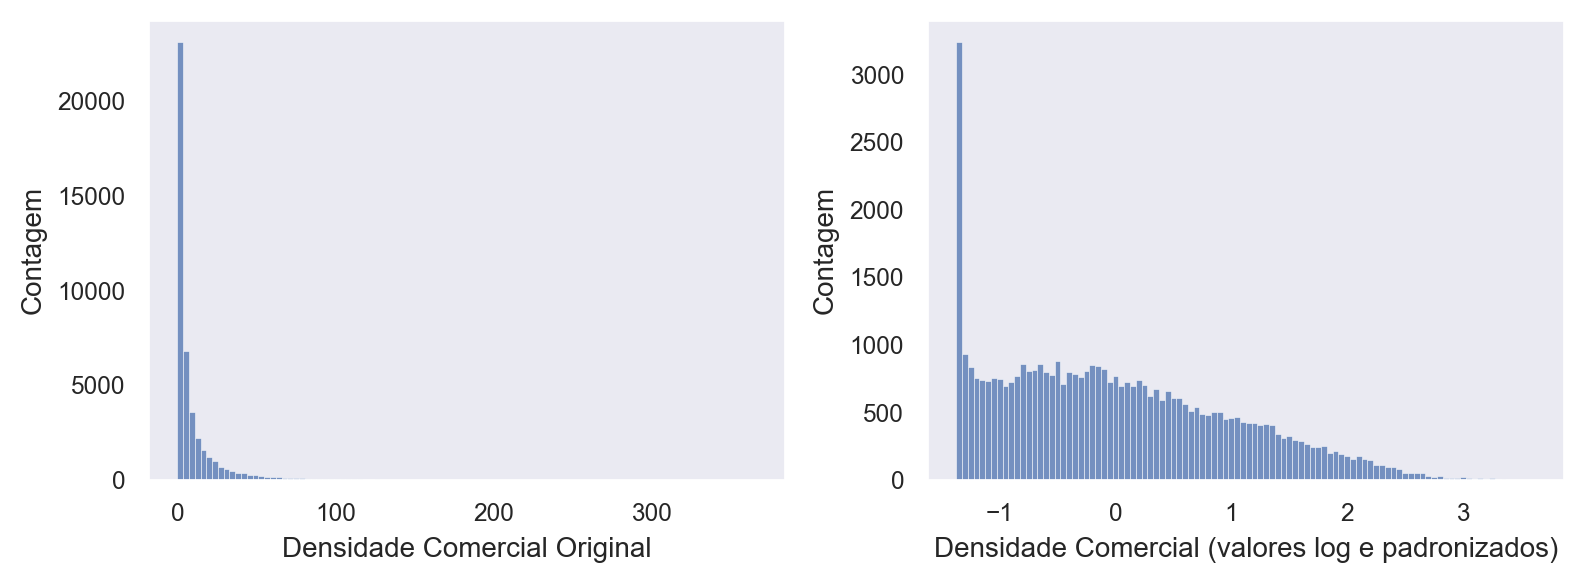

In [18]:
f, axes = plt.subplots(figsize=(8, 3), ncols=2)

sns.histplot(
    ax=axes[0],
    data=db['accessibility'],
    bins=100,
)
axes[0].set_xlabel("Densidade Comercial Original", fontsize=10)
axes[0].set_ylabel("Contagem", fontsize=10)


sns.histplot(
    ax=axes[1],
    data=y['accessibility'],
    bins=100,
)
axes[1].set_xlabel("Densidade Comercial (valores log e padronizados)", fontsize=10)
axes[1].set_ylabel("Contagem", fontsize=10)

plt.tight_layout()
plt.show()

In [19]:
df.corr(method='spearman')

,accessibility,hill_q1,income_beta_public,income_betweenness_beta_walk,households_beta_public,households_betweenness_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope,has_retail
accessibility,1.00,0.50,0.74,0.57,0.56,0.30,0.18,-0.15,0.51,0.44,0.40,-0.11,0.86
hill_q1,0.50,1.00,0.51,0.41,0.48,0.32,0.05,0.03,0.31,0.15,0.15,-0.21,0.42
income_beta_public,0.74,0.51,1.00,0.60,0.85,0.34,0.25,-0.15,0.52,0.36,0.37,-0.15,0.63
income_betweenness_beta_walk,0.57,0.41,0.60,1.00,0.57,0.89,0.13,-0.07,0.32,0.25,0.19,-0.10,0.47
households_beta_public,0.56,0.48,0.85,0.57,1.00,0.45,0.18,-0.10,0.40,0.21,0.23,-0.19,0.45
households_betweenness_beta_walk,0.30,0.32,0.34,0.89,0.45,1.00,0.03,0.04,0.11,0.04,0.00,-0.05,0.22
bueiros,0.18,0.05,0.25,0.13,0.18,0.03,1.00,-0.06,0.26,0.23,0.24,-0.09,0.13
obstaculo_calcada,-0.15,0.03,-0.15,-0.07,-0.10,0.04,-0.06,1.00,-0.29,-0.05,-0.17,0.15,-0.14
rampa_cadeirante,0.51,0.31,0.52,0.32,0.40,0.11,0.26,-0.29,1.00,0.48,0.42,-0.26,0.44
com_arvores,0.44,0.15,0.36,0.25,0.21,0.04,0.23,-0.05,0.48,1.00,0.34,-0.06,0.36


C:\Users\brand\AppData\Local\Temp\ipykernel_27820\1394363231.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


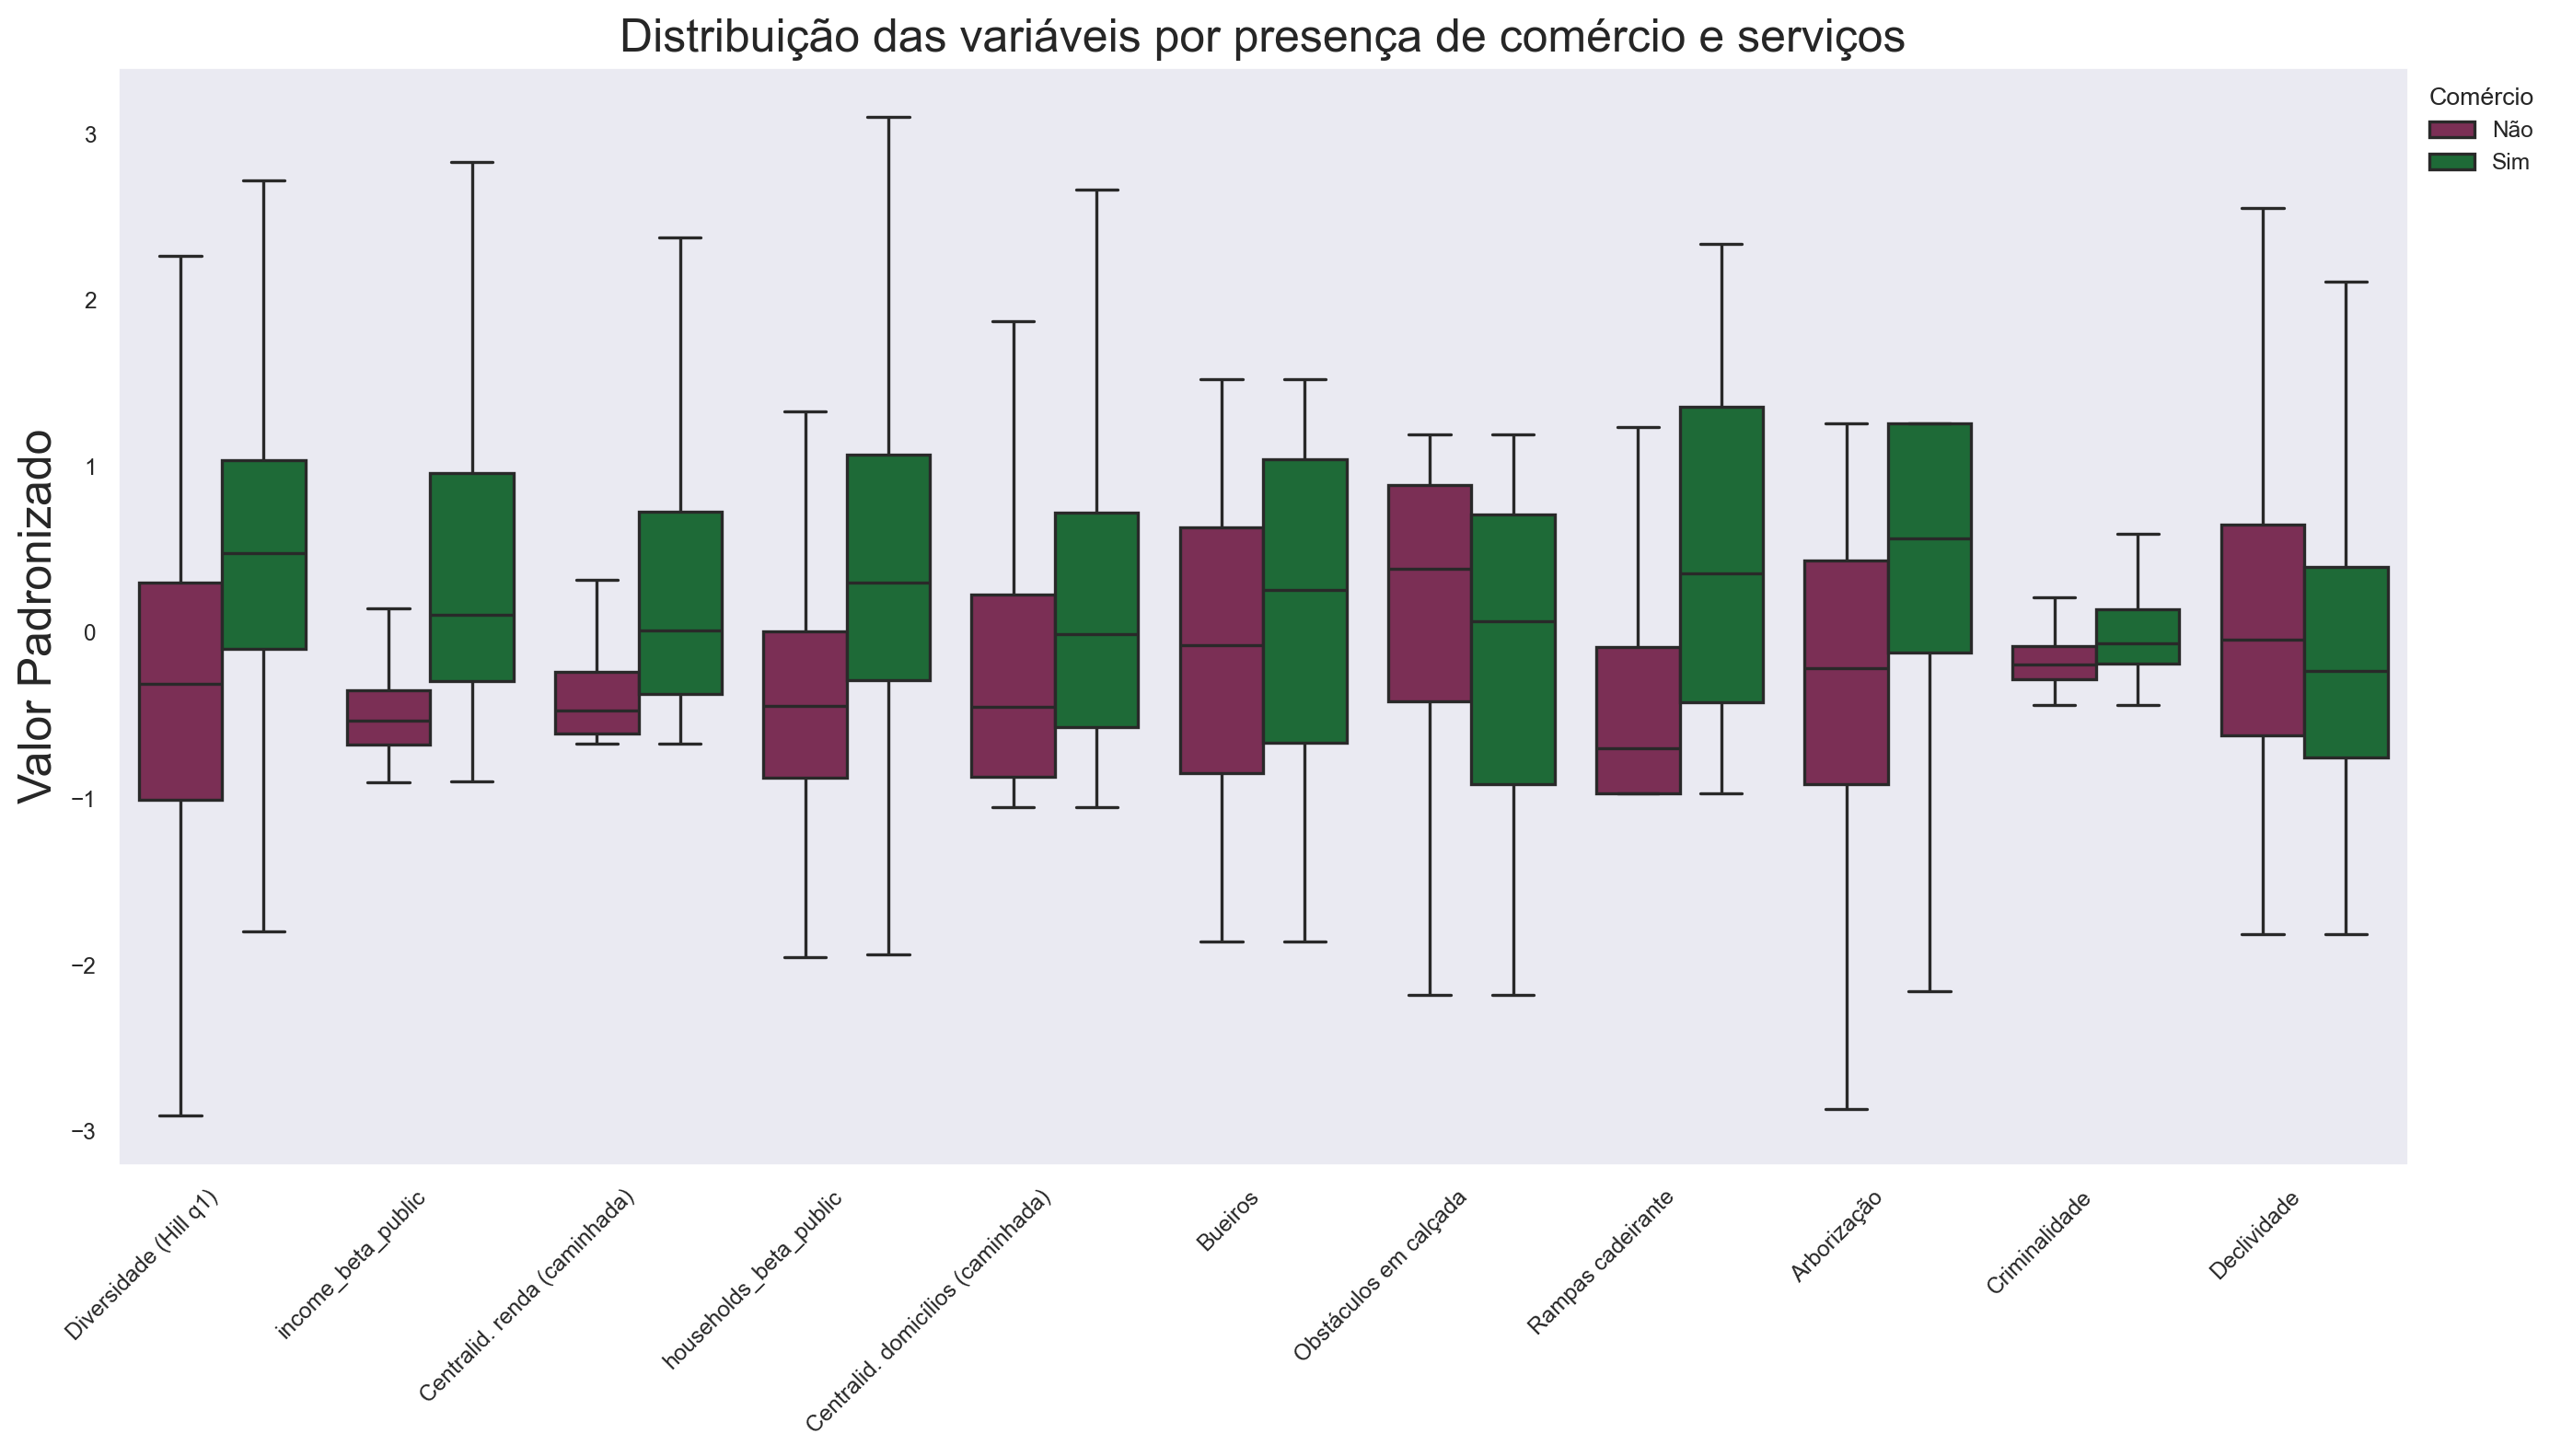

In [20]:
df_long = df.drop(columns=['accessibility']).melt(
    id_vars="has_retail",
    var_name="variable",
    value_name="value"
).replace({"has_retail": {0: "Não", 1: "Sim"}})

rename_dict = {
    "hill_q1": "Diversidade (Hill q1)",
    "income_harmonic_public": "Acess. renda (TP)",
    "income_betweenness_beta_walk": "Centralid. renda (caminhada)",
    "households_harmonic_public": "Acess. domicílios (TP)",
    "households_betweenness_beta_walk": "Centralid. domicílios (caminhada)",
    "bueiros": "Bueiros",
    "obstaculo_calcada": "Obstáculos em calçada",
    "rampa_cadeirante": "Rampas cadeirante",
    "com_arvores": "Arborização",
    "crime_rate": "Criminalidade",
    "slope": "Declividade"
}
df_long = df_long.replace({'variable': rename_dict})

# --- Plot ---
plt.figure(figsize=(14, 8))

palette = {
    'Não': "#882255",   # azul — sem comércio
    'Sim': "#117733"    # laranja — com comércio
}

ax = sns.boxplot(
    data=df_long,
    x="variable",
    y="value",
    hue="has_retail",
    showfliers=False,
    linewidth=1.2,
    palette=palette,
)

# --- Eixo x mais limpo ---
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Valor Padronizado", fontsize=18)

# --- Título e legendas ---
ax.legend(
    title="Comércio",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False
)
plt.title("Distribuição das variáveis por presença de comércio e serviços", fontsize=18)

# --- Margens e layout ---
plt.tight_layout()
plt.show()


## Base Regression

In [21]:
model = OLS(y, add_constant(X))
ols = model.fit()

In [22]:
style_talk = 'seaborn-talk'    #refer to plt.style.available

class LinearRegDiagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Authors:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.

        Matt Spinelli (m3spinelli@gmail.com, where 3 = r)
        (1) Fixed incorrect annotation of the top most extreme residuals in
            the Residuals vs Fitted and, especially, the Normal Q-Q plots.
        (2) Changed Residuals vs Leverage plot to match closer the y-axis
            range shown in the equivalent plot in the R package ggfortify.
        (3) Added horizontal line at y=0 in Residuals vs Leverage plot to
            match the plots in R package ggfortify and base R.
        (4) Added option for placing a vertical guideline on the Residuals
            vs Leverage plot using the rule of thumb of h = 2p/n to denote
            high leverage (high_leverage_threshold=True).
        (5) Added two more ways to compute the Cook's Distance (D) threshold:
            * 'baseR': D > 1 and D > 0.5 (default)
            * 'convention': D > 4/n
            * 'dof': D > 4 / (n - k - 1)
        (6) Fixed class name to conform to Pascal casing convention
        (7) Fixed Residuals vs Leverage legend to work with loc='best'
    """

    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-v0_8-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)
        self.nresids = len(self.residual_norm)

    def __call__(self, plot_context='seaborn-v0_8-paper', **kwargs):
        # print(plt.style.available)
        # GH#9157
        if plot_context not in plt.style.available:
            plot_context = 'default'
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(
                ax=ax[1,1],
                high_leverage_threshold = kwargs.get('high_leverage_threshold'),
                cooks_threshold = kwargs.get('cooks_threshold'))
            plt.show()

        return self.vif_table(), fig, ax,

    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.argsort(residual_abs), 0)
        abs_resid_top_3 = abs_resid[:3]
        for i in abs_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        fig = QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for i, x, y in self.__qq_top_resid(QQ.theoretical_quantiles, abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(x, y),
                ha='right',
                color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')

        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None, high_leverage_threshold=False, cooks_threshold='baseR'):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        factors = []
        if cooks_threshold == 'baseR' or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == 'convention':
            factors = [4/self.nresids]
        elif cooks_threshold == 'dof':
            factors = [4/ (self.nresids - self.nparams)]
        else:
            raise ValueError("threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)")
        for i, factor in enumerate(factors):
            label = "Cook's distance" if i == 0 else None
            xtemp, ytemp = self.__cooks_dist_line(factor)
            ax.plot(xtemp, ytemp, label=label, lw=1.25, ls='--', color='red')
            ax.plot(xtemp, np.negative(ytemp), lw=1.25, ls='--', color='red')

        if high_leverage_threshold:
            high_leverage = 2 * self.nparams / self.nresids
            if max(self.leverage) > high_leverage:
                ax.axvline(high_leverage, label='High leverage', ls='-.', color='purple', lw=1)

        ax.axhline(0, ls='dotted', color='black', lw=1.25)
        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_ylim(min(self.residual_norm)-0.1, max(self.residual_norm)+0.1)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        plt.legend(loc='best')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        return (vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y


    def __qq_top_resid(self, quantiles, top_residual_indices):
        """
        Helper generator function yielding the index and coordinates
        """
        offset = 0
        quant_index = 0
        previous_is_negative = None
        for resid_index in top_residual_indices:
            y = self.residual_norm[resid_index]
            is_negative = y < 0
            if previous_is_negative == None or previous_is_negative == is_negative:
                offset += 1
            else:
                quant_index -= offset
            x = quantiles[quant_index] if is_negative else np.flip(quantiles, 0)[quant_index]
            quant_index += 1
            previous_is_negative = is_negative
            yield resid_index, x, y


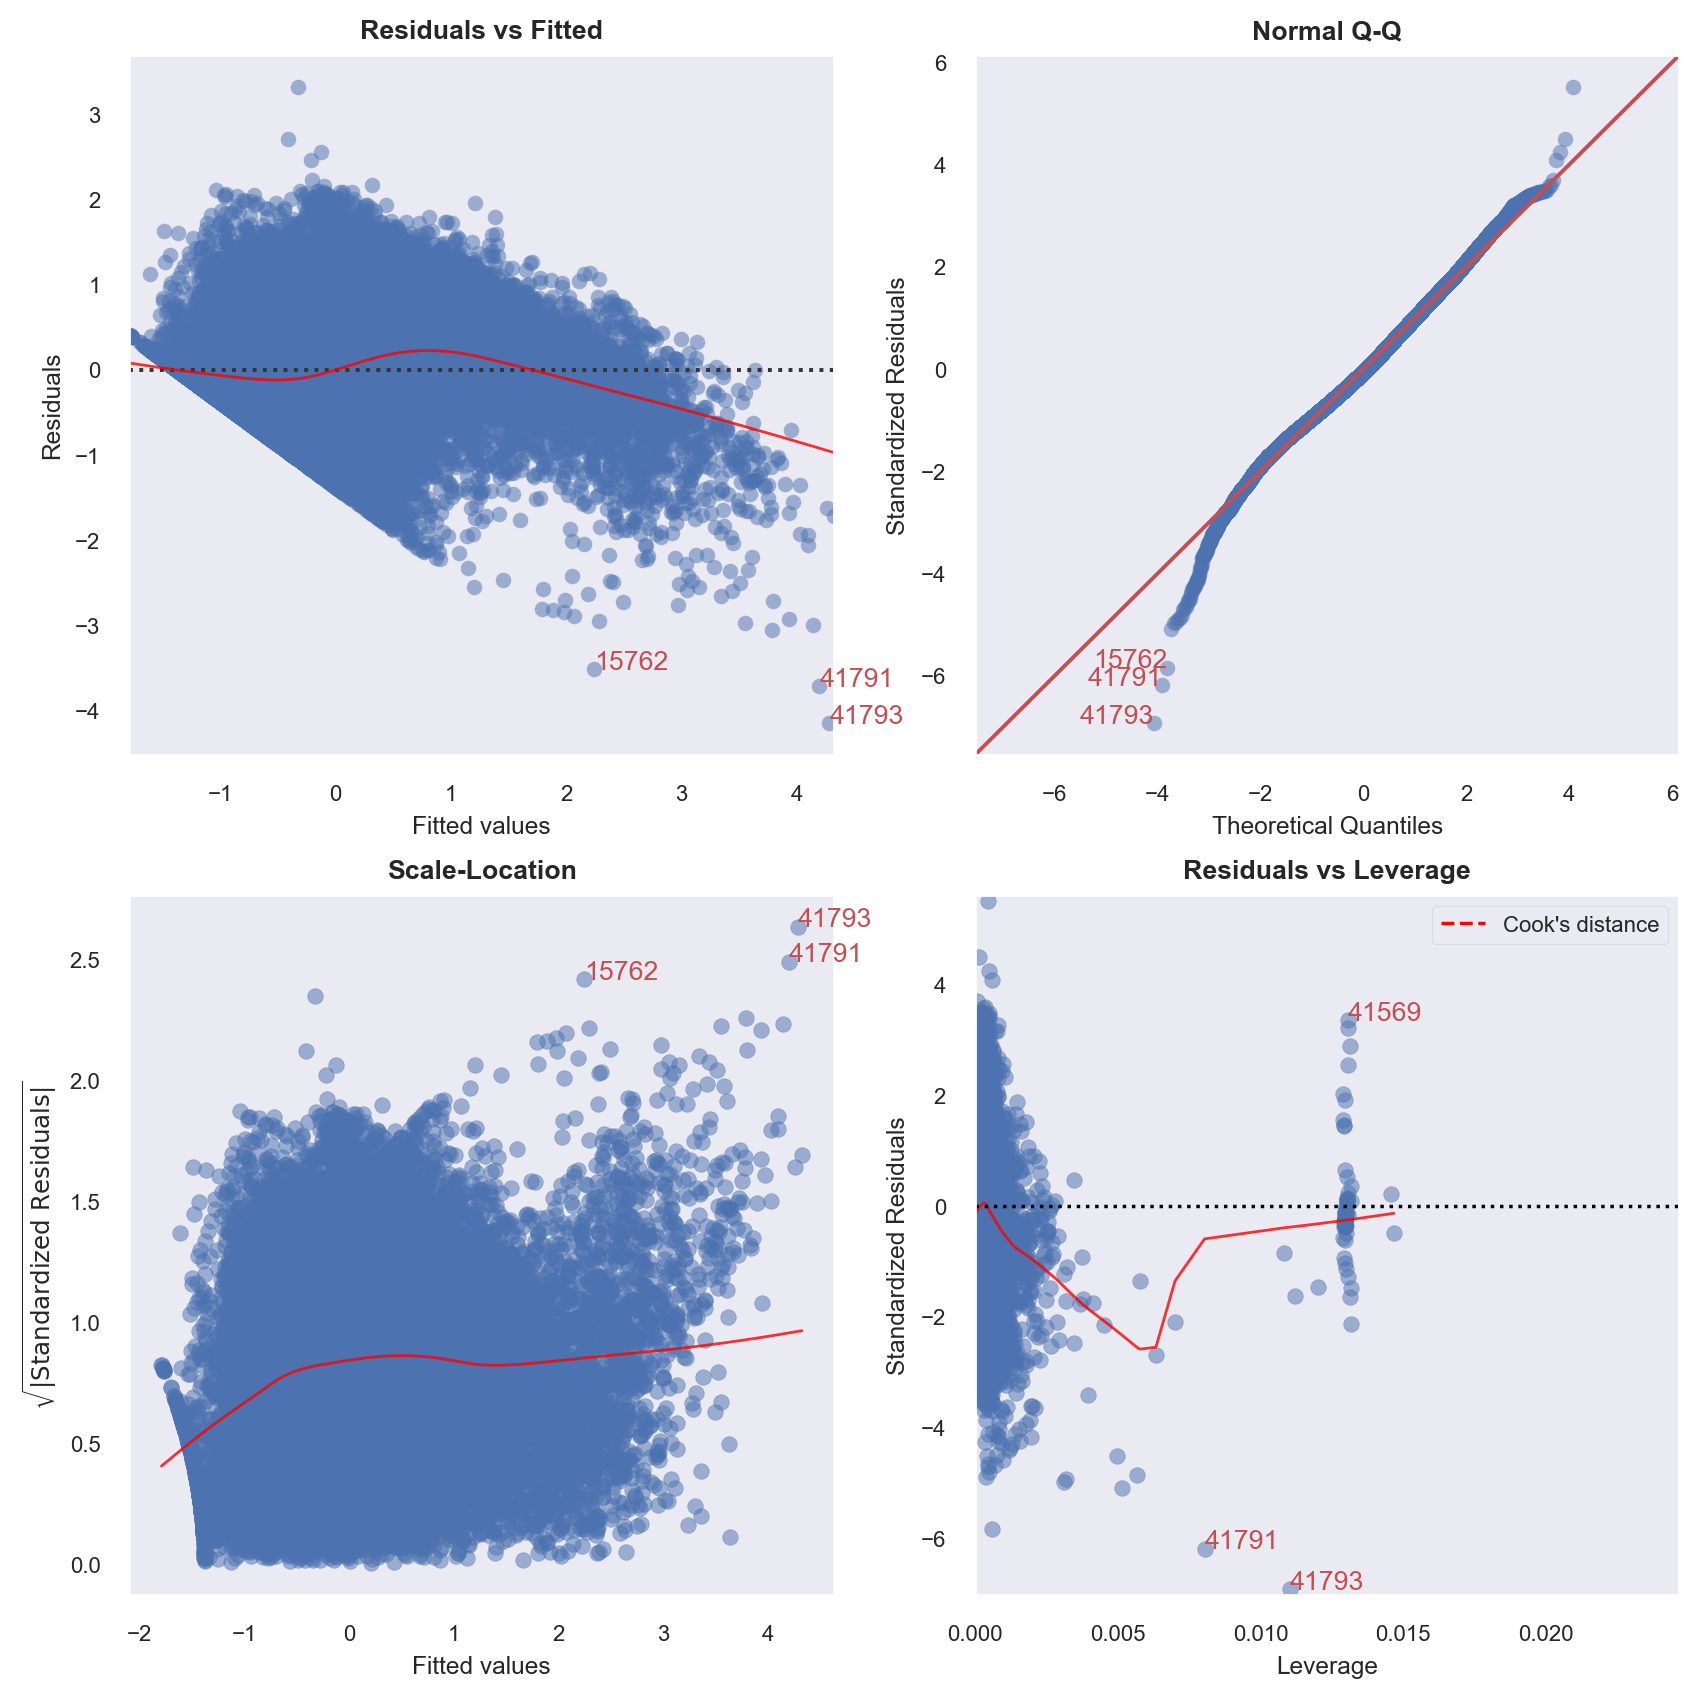

In [23]:
# Alternatively, all diagnostics can be generated in one go as follows.
# Fig and ax can be used to modify axes or plot properties after the fact.
cls = LinearRegDiagnostic(ols)
vif, fig, ax = cls()

In [24]:
vif

,Features,VIF Factor
0,const,1.00
10,crime_rate,1.08
11,slope,1.14
6,bueiros,1.16
7,obstaculo_calcada,1.32
9,com_arvores,1.42
1,hill_q1,1.43
8,rampa_cadeirante,1.99
5,households_betweenness_beta_walk,3.15
3,income_betweenness_beta_walk,4.43


In [25]:
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          accessibility   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     7057.
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:19:38   Log-Likelihood:                -40233.
No. Observations:               44140   AIC:                         8.049e+04
Df Residuals:                   44128   BIC:                         8.059e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             8.327e-17      0.003   2.91e-14      1.000      -0.006       0.006
hill_q1                              0.3133      0.003     91.441      0.000       0.307       0.320
income_beta_public                   0.6230      0.008     74.614      0.000       0.607       0.639
income_betweenness_beta_walk         0.1056      0.006     17.510      0.000       0.094       0.117
households_beta_public              -0.2002      0.007    -28.099      0.000      -0.214      -0.186
households_betweenness_beta_walk     0.0076      0.005      1.490      0.136      -0.002       0.018
bueiros                             -0.0452      0.003    -14.675      0.000      -0.051      -0.039
obstaculo_calcada                    0.0033      0.003      0.994      0.320      -0.003       0.010
rampa_cadeirante                     0.1265      0.004     31.323      0.000       0.119       0.134
com_arvores                          0.1412      0.003     41.313      0.000       0.135       0.148
crime_rate                          -0.0160      0.003     -5.394      0.000      -0.022      -0.010
slope                                0.0465      0.003     15.172      0.000       0.040       0.052
==============================================================================
Omnibus:                      415.135   Durbin-Watson:                   0.783
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              594.784
Skew:                           0.114   Prob(JB):                    6.99e-130
Kurtosis:                       3.521   Cond. No.                         7.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# XGBoost and GEOShapley

In [ ]:
# xgb_cuda_optuna_single_stage_readable_modular.py
"""
Compact, notebook-friendly XGBoost+Optuna tuning with:
- GPU device auto-handling for inplace_predict (CPU→GPU via CuPy).
- Loss selection: 'rmsle' (default), 'rmse', 'mae', 'tweedie'.
- Coherent conditional search space (depthwise vs lossguide).
"""

# ============================== Metrics =====================================

def compute_r2(true_values: np.ndarray, predicted_values: np.ndarray) -> float:
    return r2_score(true_values, predicted_values)

def compute_rmse(
    true_values: np.ndarray, predicted_values: np.ndarray
) -> float:
    return root_mean_squared_error(true_values, predicted_values)

def compute_mae(
    true_values: np.ndarray, predicted_values: np.ndarray
) -> float:
    return mean_absolute_error(true_values, predicted_values)

def compute_rmsle_safe(
    true_values: np.ndarray, predicted_values: np.ndarray
) -> float:
    # Retain clipping for safety, then use scikit-learn's robust metric
    safe_true = np.maximum(0.0, true_values)
    safe_pred = np.maximum(0.0, predicted_values)
    msle = mean_squared_log_error(safe_true, safe_pred)
    return np.sqrt(msle)

# ============================== Data prep ===================================

@dataclass
class PreparedDataset:
    feature_matrix: np.ndarray
    target_vector: np.ndarray
    feature_names: Sequence[str]
    target_name: str
    target_is_log1p: bool
    logged_feature_names: List[str]

def prepare_modeling_dataset(
    source_data_frame,
    feature_names: Sequence[str],
    target_name: str,
    *,
    apply_log1p_to_target: bool = False,
    feature_names_to_log_transform: Optional[Sequence[str]] = None,
) -> PreparedDataset:
    features = source_data_frame[feature_names].copy()
    columns_to_log = list(feature_names_to_log_transform or [])
    for column_name in columns_to_log:
        features[column_name] = np.log1p(features[column_name])

    target = source_data_frame[target_name].to_numpy().astype(float)
    if apply_log1p_to_target:
        target = np.log1p(target)

    return PreparedDataset(
        feature_matrix=features.to_numpy(),
        target_vector=target,
        feature_names=feature_names,
        target_name=target_name,
        target_is_log1p=apply_log1p_to_target,
        logged_feature_names=columns_to_log,
    )

# ====================== Cross-validation generators ==========================

def generate_spatial_cv_folds(
    coordinate_matrix: np.ndarray,
    *,
    number_of_folds: int = 5,
    random_seed_value: int = 42,
) -> Iterable[Tuple[np.ndarray, np.ndarray]]:
    kmeans = KMeans(
        n_clusters=number_of_folds,
        random_state=random_seed_value,
        n_init="auto",
    )
    cluster_labels = kmeans.fit(coordinate_matrix).labels_
    for cluster_id in range(number_of_folds):
        validation_indices = np.where(cluster_labels == cluster_id)[0]
        training_indices = np.where(cluster_labels != cluster_id)[0]
        yield training_indices, validation_indices

def build_cross_validation_folds(
    feature_matrix: np.ndarray,
    target_vector: np.ndarray,
    *,
    use_spatial_cv: bool,
    coordinates: Optional[np.ndarray],
    number_of_folds: int,
    seed: int,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    if use_spatial_cv:
        return list(
            generate_spatial_cv_folds(
                coordinate_matrix=coordinates,
                number_of_folds=number_of_folds,
                random_seed_value=seed,
            )
        )
    kfold_generator = KFold(
        n_splits=number_of_folds, shuffle=True, random_state=seed
    )
    return list(kfold_generator.split(feature_matrix, target_vector))

# =========================== Result containers ===============================

@dataclass
class CrossValidationHistory:
    training_metric_curves: List[List[float]]
    validation_metric_curves: List[List[float]]
    metric_name: str

@dataclass
class TuningOutcome:
    best_hyperparameters: Dict
    best_study_objective_value: float
    post_tuning_cv_mean_score: float
    post_tuning_cv_scores_by_fold: List[float]
    end_of_training_generalization_gap: float
    num_boost_rounds_per_refit: List[int]
    chosen_num_boost_rounds: int
    study: optuna.Study
    final_model: xgb.Booster
    cross_validation_history: CrossValidationHistory
    post_tuning_r2_mean: float
    post_tuning_r2_scores_by_fold: List[float]

# ========================= Device helpers (CuPy) =============================

def _try_convert_to_gpu_array(numpy_array: np.ndarray):
    try:
        import cupy as cp
        return cp.asarray(numpy_array)
    except (ImportError, Exception):
        return None

def _predict_on_array(
    booster: xgb.Booster,
    validation_features: np.ndarray,
    *,
    use_inplace_predict: bool,
    device: str,
):
    if use_inplace_predict:
        if device.startswith("cuda"):
            gpu_array = _try_convert_to_gpu_array(validation_features)
            if gpu_array is not None:
                return booster.inplace_predict(gpu_array)
        return booster.inplace_predict(validation_features)
    
    dmatrix_validation = xgb.DMatrix(validation_features)
    return booster.predict(dmatrix_validation)

# ============================ Search space ===================================

def _suggest_hyperparameters(
    trial: optuna.Trial, *, seed: int, device: str, loss_name: str
) -> Dict:
    params = {"tree_method": "hist", "device": device, "seed": seed}

    loss_map = {
        "rmsle": ("reg:squaredlogerror", "rmsle"),
        "rmse": ("reg:squarederror", "rmse"),
        "mae": ("reg:absoluteerror", "mae"),
        "tweedie": ("reg:tweedie", "tweedie-nloglik"),
    }
    objective, metric = loss_map.get(loss_name, ("reg:squarederror", "rmse"))
    params["objective"] = objective
    params["eval_metric"] = metric
    if loss_name == "tweedie":
        rho = trial.suggest_categorical(
            "tweedie_variance_power", np.arange(1.1, 2.0, 0.1).round(1).tolist()
            )
        params["tweedie_variance_power"] = rho
        # >>> required by recent XGBoost: include rho in the metric string
        params["eval_metric"] = f"tweedie-nloglik@{rho}"

    grow_policy = trial.suggest_categorical(
        "grow_policy", ["depthwise", "lossguide"]
    )
    params["grow_policy"] = grow_policy
    if grow_policy == "depthwise":
        params["max_depth"] = trial.suggest_int("max_depth", 3, 10)
    else:
        params["max_leaves"] = trial.suggest_int("max_leaves", 32, 384)

    params.update({
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 200),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-3, 1e2, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 1e1, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 20.0),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_bin": trial.suggest_int("max_bin", 128, 512, step=64),
        "sampling_method": trial.suggest_categorical(
            "sampling_method", ["uniform", "gradient_based"]
        ),
    })

    if grow_policy == "lossguide":
        params["learning_rate"] = min(params["learning_rate"], 0.06)
        if params["lambda"] < 1e-2 and params["alpha"] < 1e-2:
            params["lambda"] = max(params["lambda"], 1e-2)
            
    return params

# ============================ Objective ======================================

def create_cross_validation_objective(
    feature_matrix: np.ndarray,
    target_vector: np.ndarray,
    *,
    loss_name: str,
    number_of_folds: int,
    early_stopping_rounds: int,
    max_boost_rounds: int,
    seed: int,
    use_spatial_cv: bool,
    coordinates: Optional[np.ndarray],
    use_inplace_predict: bool,
    device: str,
) -> Tuple[Callable[[optuna.Trial], float], CrossValidationHistory]:
    
    folds = build_cross_validation_folds(
        feature_matrix,
        target_vector,
        use_spatial_cv=use_spatial_cv,
        coordinates=coordinates,
        number_of_folds=number_of_folds,
        seed=seed,
    )
    training_curves: List[List[float]] = []
    validation_curves: List[List[float]] = []

    def objective(trial: optuna.Trial) -> float:
        params = _suggest_hyperparameters(
            trial, seed=seed, device=device, loss_name=loss_name
        )
        pruning_target = f"valid-{params['eval_metric']}"
        pruning_callback = optuna.integration.XGBoostPruningCallback(
            trial, pruning_target
        )

        fold_scores: List[float] = []
        fold_training_curves, fold_validation_curves = [], []

        for train_idx, valid_idx in folds:
            train_features, valid_features = (
                feature_matrix[train_idx],
                feature_matrix[valid_idx],
            )
            train_target, valid_target = (
                target_vector[train_idx],
                target_vector[valid_idx],
            )

            dtrain = xgb.DMatrix(train_features, label=train_target)
            dvalid = xgb.DMatrix(valid_features, label=valid_target)

            evals_result: Dict[str, Dict[str, List[float]]] = {}
            booster = xgb.train(
                params=params,
                dtrain=dtrain,
                num_boost_round=max_boost_rounds,
                evals=[(dtrain, "train"), (dvalid, "valid")],
                early_stopping_rounds=early_stopping_rounds,
                verbose_eval=False,
                callbacks=[pruning_callback],
                evals_result=evals_result,
            )

            fold_training_curves.append(
                evals_result["train"][params["eval_metric"]]
            )
            fold_validation_curves.append(
                evals_result["valid"][params["eval_metric"]]
            )

            predictions = _predict_on_array(
                booster,
                valid_features,
                use_inplace_predict=use_inplace_predict,
                device=device,
            )
            
            # Ensure predictions are a NumPy array for metrics
            if hasattr(predictions, "get"):
                predictions = predictions.get()
            
            score_computers = {
                "rmsle": compute_rmsle_safe,   # optimize by RMSLE
                "mae": compute_mae,            # optimize by MAE
                "tweedie": compute_rmsle_safe  # <<< optimize Tweedie runs by RMSLE
            }
            computer = score_computers.get(loss_name, compute_rmse)
            score = computer(valid_target, predictions)
            fold_scores.append(score)

        trial.set_user_attr("train_curves", fold_training_curves)
        trial.set_user_attr("valid_curves", fold_validation_curves)

        training_curves[:] = fold_training_curves
        validation_curves[:] = fold_validation_curves
        return np.mean(fold_scores)

    cv_history = CrossValidationHistory(
        training_metric_curves=training_curves,
        validation_metric_curves=validation_curves,
        metric_name=loss_name,
    )

    return objective, cv_history

# ============================== Driver =======================================

def run_xgboost_optuna_tuning(
    prepared_dataset: PreparedDataset,
    *,
    loss_name: str = "rmsle",
    number_of_folds: int = 5,
    early_stopping_rounds: int = 50,
    max_boost_rounds: int = 10_000,
    number_of_optuna_trials: int = 80,
    random_seed_value: int = 42,
    use_spatial_cv: bool = False,
    coordinate_matrix: Optional[np.ndarray] = None,
    use_inplace_predict: bool = False,
    enqueue_baseline_trial: bool = False,
    device: str = "cuda",
) -> TuningOutcome:
    
    feature_matrix = prepared_dataset.feature_matrix
    target_vector = prepared_dataset.target_vector

    objective_fn, cv_history = create_cross_validation_objective(
        feature_matrix,
        target_vector,
        loss_name=loss_name,
        number_of_folds=number_of_folds,
        early_stopping_rounds=early_stopping_rounds,
        max_boost_rounds=max_boost_rounds,
        seed=random_seed_value,
        use_spatial_cv=use_spatial_cv,
        coordinates=coordinate_matrix,
        use_inplace_predict=use_inplace_predict,
        device=device,
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(
            seed=random_seed_value, multivariate=True, group=True
        ),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=25),
    )

    if enqueue_baseline_trial:
        baseline_params = {
            "grow_policy": "depthwise", "max_depth": 6,
            "min_child_weight": 20, "subsample": 0.8,
            "colsample_bytree": 0.8, "lambda": 1.0, "alpha": 1e-3,
            "gamma": 0.0, "learning_rate": 0.05, "max_bin": 256,
            "sampling_method": "uniform",
        }
        if loss_name == "tweedie":
            baseline_params["tweedie_variance_power"] = 1.5
        study.enqueue_trial(baseline_params)

    study.optimize(
        objective_fn,
        n_trials=number_of_optuna_trials,
        show_progress_bar=True,
    )
    bt = study.best_trial
    tc = bt.user_attrs.get("train_curves") or []
    vc = bt.user_attrs.get("valid_curves") or []

    # Fallback: if attrs are missing (very rare), use the last COMPLETED trial
    if not tc or not vc:
        completed = [
            t for t in study.trials
            if t.state == optuna.trial.TrialState.COMPLETE
        ]
        if completed:
            last_complete = max(completed, key=lambda t: t.number)
            tc = last_complete.user_attrs.get("train_curves") or []
            vc = last_complete.user_attrs.get("valid_curves") or []

    cv_history.training_metric_curves[:] = tc
    cv_history.validation_metric_curves[:] = vc
    if loss_name == "tweedie":
        cv_history.metric_name = "rmsle"

    best_hyperparameters = dict(study.best_trial.params)
    final_params = _suggest_hyperparameters(
        study.best_trial,
        seed=random_seed_value,
        device=device,
        loss_name=loss_name,
    )
    final_params.update(best_hyperparameters)

    # Determine optimal boosting rounds
    rounds_from_folds = []
    folds = build_cross_validation_folds(
        feature_matrix,
        target_vector,
        use_spatial_cv=use_spatial_cv,
        coordinates=coordinate_matrix,
        number_of_folds=number_of_folds,
        seed=random_seed_value,
    )
    for train_idx, valid_idx in folds:
        dtrain_aux = xgb.DMatrix(feature_matrix[train_idx], label=target_vector[train_idx])
        dvalid_aux = xgb.DMatrix(feature_matrix[valid_idx], label=target_vector[valid_idx])
        
        aux_model = xgb.train(
            params=final_params,
            dtrain=dtrain_aux,
            num_boost_round=max_boost_rounds,
            evals=[(dtrain_aux, "train"), (dvalid_aux, "valid")],
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=False,
        )
        rounds_from_folds.append(aux_model.best_iteration)
    
    chosen_rounds = int(np.mean(rounds_from_folds))

    # Retrain final model on all data with the chosen number of rounds
    dfull = xgb.DMatrix(feature_matrix, label=target_vector)
    final_model = xgb.train(
        params=final_params,
        dtrain=dfull,
        num_boost_round=chosen_rounds,
        verbose_eval=False,
    )

    # Perform a final cross-validation for an unbiased performance estimate
    post_tuning_folds = build_cross_validation_folds(
        feature_matrix,
        target_vector,
        use_spatial_cv=use_spatial_cv,
        coordinates=coordinate_matrix,
        number_of_folds=number_of_folds,
        seed=random_seed_value + 1,  # Use a different seed
    )
    scores_by_fold = []
    r2_scores_by_fold = []
    for train_idx, valid_idx in post_tuning_folds:
        train_features, valid_features = (
            feature_matrix[train_idx], feature_matrix[valid_idx]
        )
        train_target, valid_target = (
            target_vector[train_idx], target_vector[valid_idx]
        )
        dtrain = xgb.DMatrix(train_features, label=train_target)
        booster = xgb.train(
            params=final_params,
            dtrain=dtrain,
            num_boost_round=chosen_rounds,
            verbose_eval=False,
        )
        predictions = _predict_on_array(
            booster,
            valid_features,
            use_inplace_predict=use_inplace_predict,
            device=final_params.get("device", "cpu"),
        )
        
        # Ensure predictions are a NumPy array for metrics
        if hasattr(predictions, "get"):
            predictions = predictions.get()
            
        score_computers = {
            "rmsle": compute_rmsle_safe, "mae": compute_mae,
            "tweedie": compute_rmsle_safe  # <<< optimize Tweedie runs by RMSLE
        }
        computer = score_computers.get(loss_name, compute_rmse)
        score = computer(valid_target, predictions)
        scores_by_fold.append(score)

        r2_scores_by_fold.append(r2_score(valid_target, predictions))

    post_tuning_r2_mean = float(np.mean(r2_scores_by_fold))

    def _mean_of_last_values(curves: List[List[float]]) -> float:
        last_values = [curve[-1] for curve in curves if curve]
        return np.mean(last_values) if last_values else float("nan")

    train_end_score = _mean_of_last_values(cv_history.training_metric_curves)
    valid_end_score = _mean_of_last_values(cv_history.validation_metric_curves)
    generalization_gap = valid_end_score - train_end_score

    return TuningOutcome(
        best_hyperparameters=best_hyperparameters,
        best_study_objective_value=study.best_value,
        post_tuning_cv_mean_score=np.mean(scores_by_fold),
        post_tuning_cv_scores_by_fold=scores_by_fold,
        end_of_training_generalization_gap=generalization_gap,
        num_boost_rounds_per_refit=[chosen_rounds] * number_of_folds,
        chosen_num_boost_rounds=chosen_rounds,
        study=study,
        final_model=final_model,
        cross_validation_history=cv_history,
        post_tuning_r2_mean=post_tuning_r2_mean,
        post_tuning_r2_scores_by_fold=r2_scores_by_fold,
    )

# ============================ Visualization ==================================

def plot_mean_learning_curves_with_confidence_band(
    cv_history: CrossValidationHistory,
):
    train_curves = cv_history.training_metric_curves
    valid_curves = cv_history.validation_metric_curves
    if not train_curves or not valid_curves:
        print("No learning curves available to plot.")
        return

    min_len = min(min(map(len, train_curves)), min(map(len, valid_curves)))
    train_matrix = np.array([curve[:min_len] for curve in train_curves])
    valid_matrix = np.array([curve[:min_len] for curve in valid_curves])
    
    mean_train, std_train = train_matrix.mean(0), train_matrix.std(0)
    mean_valid, std_valid = valid_matrix.mean(0), valid_matrix.std(0)
    rounds_axis = np.arange(len(mean_train))

    plt.figure(figsize=(10, 5))
    plt.plot(rounds_axis, mean_train, label="Train")
    plt.plot(rounds_axis, mean_valid, label="Validation")
    plt.fill_between(
        rounds_axis, mean_train - std_train, mean_train + std_train, alpha=0.2
    )
    plt.fill_between(
        rounds_axis, mean_valid - std_valid, mean_valid + std_valid, alpha=0.2
    )
    plt.xlabel("Boosting Round")
    plt.ylabel(cv_history.metric_name.upper())
    plt.title("Learning Curves (Mean ± 1 Standard Deviation)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [139]:
# 1) Define names and prepare data
target_name = "accessibility"

# Define feature names as all columns except the target and coordinates
# (keep your original intent; just make sure we reference the same df)
feature_names = (
    df.drop(columns=[target_name, "has_retail"]).columns.tolist() + ["x", "y"]
)

# Extract coordinates for spatial CV (not used here; kept for parity)
coordinates = db[["x", "y"]].to_numpy()

features_to_log = [
    "households_beta_public",
    "households_betweenness_beta_walk",
    "income_betweenness_beta_walk",
    "income_beta_public",
    "crime_rate",
]

# Adjusted to the new API names; pass your list explicitly
prepared_data = prepare_modeling_dataset(
    source_data_frame=db,
    feature_names=feature_names,
    target_name=target_name,
    apply_log1p_to_target=False,
    feature_names_to_log_transform=None,  # your list, as commented
)

In [ ]:
tuning_random_cv = run_xgboost_optuna_tuning(
    prepared_dataset=prepared_data,
    loss_name="tweedie",                # or "rmse", "mae", "tweedie"
    number_of_folds=5,
    early_stopping_rounds=50,
    max_boost_rounds=10_000,
    number_of_optuna_trials=50,
    random_seed_value=42,
    use_spatial_cv=False,
    coordinate_matrix=None,
    use_inplace_predict=True,         # For GPU-accelerated prediction
    enqueue_baseline_trial=True,
    device="cuda",                    # "cuda" or "cpu"
)

# --- Display key results ---
print(f"Best objective value: {tuning_random_cv.best_study_objective_value:.5f}")
print(f"Post-tuning OOF mean score: {tuning_random_cv.post_tuning_cv_mean_score:.5f}")
print(f"Generalization gap (Valid - Train): {tuning_random_cv.end_of_training_generalization_gap:.5f}")
print(f"Chosen boosting rounds: {tuning_random_cv.chosen_num_boost_rounds}")
print("\nBest hyperparameters:", tuning_random_cv.best_hyperparameters)

# --- Plot learning curves from the best trial ---
plot_mean_learning_curves_with_confidence_band(
    cv_history=tuning_random_cv.cross_validation_history
)

c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-10-20 16:52:05,618] A new study created in memory with name: no-name-5bfb9ee2-5197-43de-8594-aa275b12fea2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-10-20 16:53:28,769] Trial 0 finished with value: 0.43537904490394996 and parameters: {'tweedie_variance_power': 1.5, 'grow_policy': 'depthwise', 'max_depth': 6, 'min_child_weight': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'lambda': 1.0, 'alpha': 0.001, 'gamma': 0.0, 'learning_rate': 0.05, 'max_bin': 256, 'sampling_method': 'uniform'}. Best is trial 0 with value: 0.43537904490394996.
[I 2025-10-20 16:55:24,438] Trial 1 finished with value: 0.5340371554706245 and parameters: {'tweedie_variance_power': 1.2, 'grow_policy': 'depthwise', 'max_depth': 10, 'min_child_weight': 167, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'lambda': 0.008260808399079604, 'alpha': 0.016480446427978974, 'gamma': 10.495128632644757, 'learning_rate': 0.009860942908083906, 'max_bin': 256, 'sampling_method': 'uniform'}. Best is trial 0 with value: 0.43537904490394996.
[I 2025-10-20 16:59:30,676] Trial 2 finished with value: 0.5364621103800407 and parameters: {'tweedie_vari

In [ ]:
import optuna.visualization as vis

display(vis.plot_param_importances(tuning_random_cv.study))
display(vis.plot_optimization_history(tuning_random_cv.study))

c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-10-20 15:45:22,368] A new study created in memory with name: no-name-5ce56dfc-4bad-4162-a975-b9cdc31e1a31


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-10-20 15:45:40,316] Trial 0 finished with value: 0.693866114867167 and parameters: {'grow_policy': 'depthwise', 'max_depth': 6, 'min_child_weight': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'lambda': 1.0, 'alpha': 0.001, 'gamma': 0.0, 'learning_rate': 0.05, 'max_bin': 256, 'sampling_method': 'uniform'}. Best is trial 0 with value: 0.693866114867167.
[I 2025-10-20 15:45:43,215] Trial 1 finished with value: 1.46417672145681 and parameters: {'grow_policy': 'lossguide', 'max_leaves': 290, 'min_child_weight': 120, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'lambda': 0.0019517224641449498, 'alpha': 2.9154431891537547, 'gamma': 12.022300234864176, 'learning_rate': 0.04258888210290081, 'max_bin': 128, 'sampling_method': 'uniform'}. Best is trial 0 with value: 0.693866114867167.
[I 2025-10-20 15:46:15,220] Trial 2 finished with value: 0.7399436303538351 and parameters: {'grow_policy': 'depthwise', 'max_depth': 4, 'min_child_weight': 61, 'subsample': 0.

c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\optuna\pruners\_percentile.py:21: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(values)


[I 2025-10-20 15:46:54,429] Trial 21 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:54,713] Trial 22 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:55,414] Trial 23 pruned. Trial was pruned at iteration 145.
[I 2025-10-20 15:46:55,738] Trial 24 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:56,038] Trial 25 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:56,418] Trial 26 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:56,623] Trial 27 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:57,048] Trial 28 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:57,286] Trial 29 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:57,672] Trial 30 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:46:58,142] Trial 31 pruned. Trial was pruned at iteration 25.
[I 2025-10-20 15:47:02,443] Trial 32 finished with value: 0.78603229261608 and parameters: {'grow_policy': 'lossguide', 'max_leave

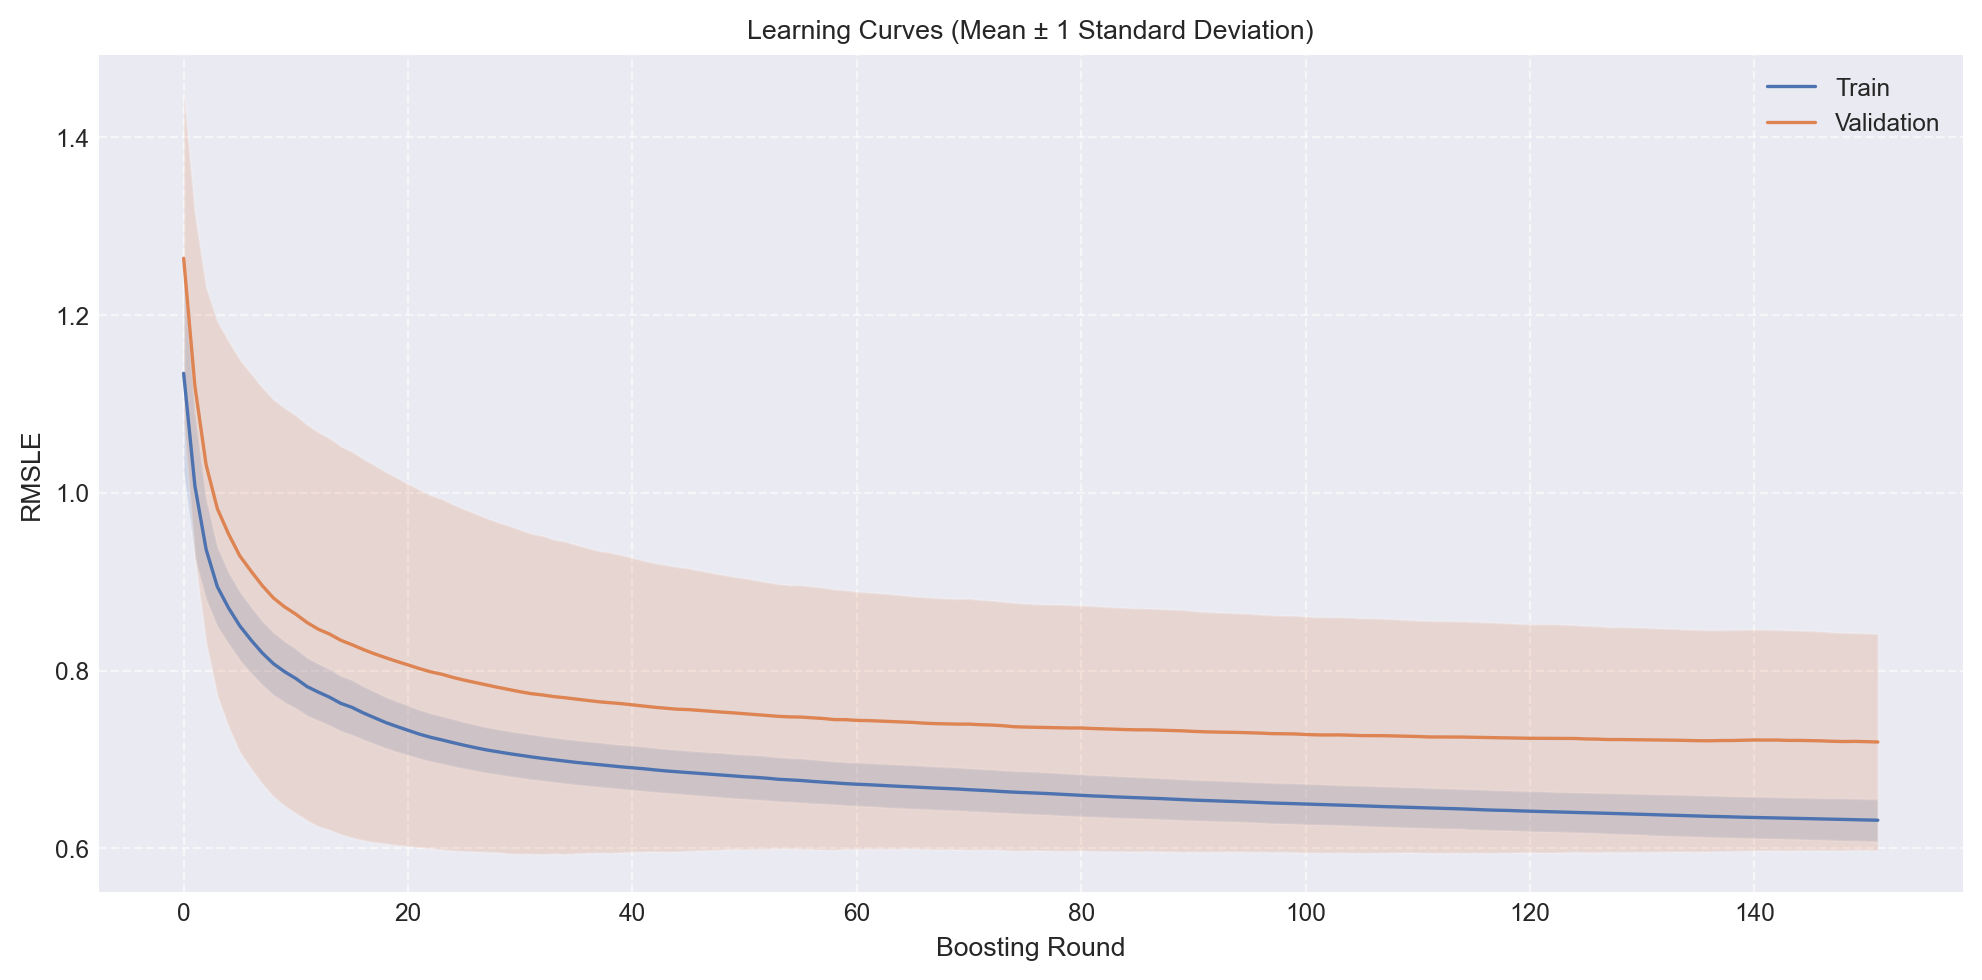

In [ ]:
tuning_spatial_cv = run_xgboost_optuna_tuning(
    prepared_dataset=prepared_data,
    loss_name="tweedie",                # or "rmse", "mae", "tweedie"
    number_of_folds=5,
    early_stopping_rounds=50,
    max_boost_rounds=10_000,
    number_of_optuna_trials=50,
    random_seed_value=42,
    use_spatial_cv=True,
    coordinate_matrix=coordinates,
    use_inplace_predict=True,         # For GPU-accelerated prediction
    enqueue_baseline_trial=True,
    device="cuda",                    # "cuda" or "cpu"
)

# --- Display key results ---
print(f"Best objective value: {tuning_spatial_cv.best_study_objective_value:.5f}")
print(f"Post-tuning OOF mean score: {tuning_spatial_cv.post_tuning_cv_mean_score:.5f}")
print(f"Generalization gap (Valid - Train): {tuning_spatial_cv.end_of_training_generalization_gap:.5f}")
print(f"Chosen boosting rounds: {tuning_spatial_cv.chosen_num_boost_rounds}")
print("\nBest hyperparameters:", tuning_spatial_cv.best_hyperparameters)

# --- Plot learning curves from the best trial ---
plot_mean_learning_curves_with_confidence_band(
    cv_history=tuning_spatial_cv.cross_validation_history
)

In [ ]:
display(vis.plot_param_importances(tuning_spatial_cv.study))
display(vis.plot_optimization_history(tuning_spatial_cv.study))

 Absolutely. For the **refit bootstrap with out-of-bag (OOB) evaluation**—i.e.,
resampling the training pool, refitting the fixed hyperparameters each time, and
evaluating on the OOB portion—these are the most relevant, reputable sources:

1. **Efron & Tibshirani (1997), JASA — “Improvements on Cross-Validation:
   The .632+ Bootstrap Method.”**
   Canonical reference for using bootstrap resamples to **fit the model** and
   assess prediction error on OOB data; the .632 and .632+ estimators correct
   the optimism of the resubstitution error and are widely used for internal
   validation of predictive models. ([Taylor & Francis Online][1])

2. **Efron (1979), Annals of Statistics — “Bootstrap Methods: Another Look at
   the Jackknife.”**
   Foundational paper introducing the bootstrap, including the nonparametric
   scheme you leverage when drawing resamples of the training data. ([projecteuclid.org][2])

3. **Davison & Hinkley (1997), *Bootstrap Methods and Their Application*
   (Cambridge).**
   A rigorous monograph covering theory and practice of bootstrap estimators,
   confidence intervals, and prediction-error assessment; gives the formal
   grounding for refit-style bootstrap procedures. ([Cambridge University Press & Assessment][3])

4. **Harrell (2015), *Regression Modeling Strategies* (2nd ed.).**
   Detailed treatment of **bootstrap validation** for predictive performance,
   including **optimism correction** by refitting on bootstrap samples and
   evaluating on OOB—very close to what you plan to do. ([Nibme Hub][4])

5. **Hastie, Tibshirani & Friedman (2009), *The Elements of Statistical
   Learning* (2nd ed.).**
   Standard reference that discusses resampling-based error estimation,
   including bootstrap ideas in model assessment/selection. ([hastie.su.domains][5])

6. **Kuhn & Johnson (2013), *Applied Predictive Modeling* (Springer).**
   Practical guide to internal validation workflows (bootstrap vs. CV), model
   optimism, and performance estimation in supervised learning. ([ic.unicamp.br][6])

7. **Iba et al. (2021), *BMC Medical Research Methodology*.**
   Contemporary comparative study emphasizing **Harrell’s optimism-corrected
   bootstrap** and the **.632/.632+** estimators as strong choices for internal
   validation of prediction models. ([BioMed Central][7])

---

### How these map to your plan

* Your “refit on bootstrap, evaluate on OOB” mirrors the **.632/.632+** logic
  (Efron & Tibshirani) and the **optimism-corrected bootstrap** (Harrell).
* Use these to report not only point estimates (e.g., RMSE) but also **CIs**
  via the bootstrap distribution (Davison & Hinkley).
* Keep **hyperparameters fixed** (set in Stage 2), refit the final model per
  replicate, and evaluate on the OOB subset; optionally aggregate via .632+ to
  correct residual optimism (Efron & Tibshirani; ESL, APM). ([Taylor & Francis Online][1])

If you’d like, I can add a switch in your pipeline to compute a **.632+ RMSE
estimate** (alongside plain OOB and test-bootstrap CIs) and print a compact
summary table.

[1]: https://www.tandfonline.com/doi/abs/10.1080/01621459.1997.10474007?utm_source=chatgpt.com "Improvements on Cross-Validation: The 632+ Bootstrap ..."
[2]: https://projecteuclid.org/journals/annals-of-statistics/volume-7/issue-1/Bootstrap-Methods-Another-Look-at-the-Jackknife/10.1214/aos/1176344552.full?utm_source=chatgpt.com "Bootstrap Methods: Another Look at the Jackknife"
[3]: https://www.cambridge.org/core/books/bootstrap-methods-and-their-application/ED2FD043579F27952363566DC09CBD6A?utm_source=chatgpt.com "Bootstrap Methods and their Application"
[4]: https://nibmehub.com/opac-service/pdf/read/Regression%20Modeling%20Strategies-%202nd%20edition-%202015.pdf?utm_source=chatgpt.com "Frank E. Harrell, Jr. - Regression Modeling Strategies"
[5]: https://hastie.su.domains/ElemStatLearn/?utm_source=chatgpt.com "Elements of Statistical Learning - Trevor Hastie"
[6]: https://www.ic.unicamp.br/~wainer/cursos/1s2021/432/2013_Book_AppliedPredictiveModeling.pdf?utm_source=chatgpt.com "Applied Predictive Modeling - Max Kuhn · Kjell Johnson"
[7]: https://bmcmedresmethodol.biomedcentral.com/articles/10.1186/s12874-020-01201-w?utm_source=chatgpt.com "Re-evaluation of the comparative effectiveness of bootstrap ..."


In [ ]:
# xgb_bootstrap_refit.py
# Interrupt-safe refit bootstrap for final XGBoost model evaluation.

from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Dict, Sequence, Optional, Tuple
import csv

import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from joblib import dump, load


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    diff = y_true - y_pred
    return float(np.sqrt(np.mean(diff * diff)))


def transform_target_forward(
    y: np.ndarray, log1p_target: bool
) -> np.ndarray:
    return np.log1p(y) if log1p_target else y


def transform_target_inverse(
    y_transformed: np.ndarray,
    y_scaler: Optional[StandardScaler],
    log1p_target: bool,
) -> np.ndarray:
    y = y_transformed
    if y_scaler is not None:
        y = y_scaler.inverse_transform(y.reshape(-1, 1)).ravel()
    if log1p_target:
        y = np.expm1(y)
    return y


def fit_scalers_on_sample(
    X_sample: np.ndarray,
    y_sample_transformed: np.ndarray,
    scale_features: bool,
    scale_target: bool,
) -> Tuple[Optional[StandardScaler], Optional[StandardScaler]]:
    x_scaler = StandardScaler().fit(X_sample) if scale_features else None
    y_scaler = (StandardScaler()
                .fit(y_sample_transformed.reshape(-1, 1))
                if scale_target else None)
    return x_scaler, y_scaler


def apply_feature_scaler(
    X: np.ndarray, x_scaler: Optional[StandardScaler]
) -> np.ndarray:
    return X if x_scaler is None else x_scaler.transform(X)


def apply_target_scaler(
    y_transformed: np.ndarray, y_scaler: Optional[StandardScaler]
) -> np.ndarray:
    if y_scaler is None:
        return y_transformed
    return y_scaler.transform(y_transformed.reshape(-1, 1)).ravel()


def save_json_atomic(path: Path, obj: Dict) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    tmp.replace(path)


def append_csv_atomic(path: Path, row: Dict[str, object]) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    write_header = not path.exists()
    with tmp.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            writer.writeheader()
        # If a prior CSV exists, copy it and append the new row.
        if path.exists():
            with path.open("r", newline="", encoding="utf-8") as r:
                reader = csv.DictReader(r)
                for old in reader:
                    writer.writerow(old)
        writer.writerow(row)
    tmp.replace(path)


def run_refit_bootstrap(
    *,
    df,
    feature_cols: Sequence[str],
    target_col: str,
    final_params: Dict,
    best_round: int,
    out_dir: str = "xgb_bootstrap",
    n_boot: int = 300,
    base_seed: int = 42,
    log1p_target: bool = True,
    scale_target: bool = True,
    scale_features: bool = True,
) -> None:
    """
    Refit-bootstrap of the final model. For each replicate:
    - sample with replacement over all rows,
    - fit scalers on the bootstrap sample,
    - fit Booster with fixed final_params and best_round,
    - evaluate on: (a) entire dataset, (b) OOB subset,
    - save model/scalers/metrics, append CSV.
    Safe to interrupt; rerun will skip completed replicates.
    """
    out_root = Path(out_dir)
    d_models = out_root / "models"
    d_scalers = out_root / "scalers"
    d_meta = out_root / "meta"
    ensure_dir(d_models); ensure_dir(d_scalers); ensure_dir(d_meta)

    results_csv = out_root / "results.csv"

    X_full = df[feature_cols].to_numpy()
    y_full = df[target_col].to_numpy()
    n_obs = len(y_full)

    # Pre-transform target once (log1p if requested).
    y_full_transformed = transform_target_forward(y_full, log1p_target)

    for b in range(n_boot):
        model_path = d_models / f"boot_{b:05d}.json"
        meta_path = d_meta / f"boot_{b:05d}.json"
        xsc_path = d_scalers / f"boot_{b:05d}_xscaler.pkl"
        ysc_path = d_scalers / f"boot_{b:05d}_yscaler.pkl"

        # Skip completed replicate (model + meta exist).
        if model_path.exists() and meta_path.exists():
            continue

        rng = np.random.default_rng(base_seed + 9973 * b)
        boot_idx = rng.integers(0, n_obs, size=n_obs)
        oob_mask = np.ones(n_obs, dtype=bool)
        oob_mask[boot_idx] = False

        X_boot = X_full[boot_idx]
        y_boot_t = y_full_transformed[boot_idx]

        # Fit scalers on bootstrap sample; transform all sets.
        x_scaler, y_scaler = fit_scalers_on_sample(
            X_sample=X_boot,
            y_sample_transformed=y_boot_t,
            scale_features=scale_features,
            scale_target=scale_target,
        )

        X_boot_s = apply_feature_scaler(X_boot, x_scaler)
        y_boot_ts = apply_target_scaler(y_boot_t, y_scaler)

        X_all_s = apply_feature_scaler(X_full, x_scaler)
        y_all_ts = apply_target_scaler(y_full_transformed, y_scaler)

        if np.any(oob_mask):
            X_oob_s = X_all_s[oob_mask]
            y_oob_ts = y_all_ts[oob_mask]
        else:
            # Degenerate (rare) case: no OOB rows
            X_oob_s = np.empty((0, X_full.shape[1]))
            y_oob_ts = np.empty((0,))

        d_boot = xgb.DMatrix(X_boot_s, label=y_boot_ts)
        d_all = xgb.DMatrix(X_all_s, label=y_all_ts)
        d_oob = xgb.DMatrix(X_oob_s, label=y_oob_ts) if len(y_oob_ts) else None

        booster = xgb.train(
            params=final_params,
            dtrain=d_boot,
            num_boost_round=best_round,
            verbose_eval=0,
        )

        # Predictions on evaluation sets (scaled space).
        y_hat_all_ts = booster.predict(d_all)
        rmse_all_scaled = rmse(y_all_ts, y_hat_all_ts)

        if d_oob is not None:
            y_hat_oob_ts = booster.predict(d_oob)
            rmse_oob_scaled = rmse(y_oob_ts, y_hat_oob_ts)
        else:
            rmse_oob_scaled = float("nan")

        # Back-transform to original units for interpretability.
        y_all_orig = transform_target_inverse(
            y_all_ts, y_scaler, log1p_target
        )
        y_hat_all_orig = transform_target_inverse(
            y_hat_all_ts, y_scaler, log1p_target
        )
        rmse_all_orig = rmse(y_all_orig, y_hat_all_orig)

        if d_oob is not None and len(y_oob_ts):
            y_oob_orig = transform_target_inverse(
                y_oob_ts, y_scaler, log1p_target
            )
            y_hat_oob_orig = transform_target_inverse(
                y_hat_oob_ts, y_scaler, log1p_target
            )
            rmse_oob_orig = rmse(y_oob_orig, y_hat_oob_orig)
        else:
            rmse_oob_orig = float("nan")

        # Persist artifacts for resume.
        booster.save_model(str(model_path))
        if x_scaler is not None:
            dump(x_scaler, xsc_path)
        if y_scaler is not None:
            dump(y_scaler, ysc_path)

        meta = {
            "replicate": b,
            "seed": int(base_seed + 9973 * b),
            "n_obs": int(n_obs),
            "n_oob": int(np.count_nonzero(oob_mask)),
            "rmse_all_scaled": rmse_all_scaled,
            "rmse_oob_scaled": rmse_oob_scaled,
            "rmse_all_orig": rmse_all_orig,
            "rmse_oob_orig": rmse_oob_orig,
            "model_path": str(model_path),
            "x_scaler_path": str(xsc_path) if x_scaler is not None else None,
            "y_scaler_path": str(ysc_path) if y_scaler is not None else None,
        }
        save_json_atomic(meta_path, meta)

        # Also append a flat row to CSV for quick aggregation.
        append_csv_atomic(results_csv, meta)


def summarize_bootstrap_results(
    out_dir: str = "xgb_bootstrap",
    metric_key: str = "rmse_oob_orig",
    alpha: float = 0.05,
) -> Dict[str, float]:
    """
    Summarize the CSV accumulated by run_refit_bootstrap, returning the
    mean and percentile CI for the selected metric_key.
    Suggested keys: 'rmse_oob_orig', 'rmse_all_orig',
                    'rmse_oob_scaled', 'rmse_all_scaled'.
    """
    path = Path(out_dir) / "results.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    values = []
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            v = row.get(metric_key)
            if v is not None and v != "" and v != "nan":
                values.append(float(v))

    if not values:
        raise ValueError(f"No valid values for '{metric_key}' in results.csv")

    arr = np.asarray(values, dtype=float)
    mean = float(np.mean(arr))
    low = float(np.quantile(arr, alpha / 2))
    high = float(np.quantile(arr, 1 - alpha / 2))
    summary = {"metric": metric_key, "mean": mean, "low": low, "high": high}
    print(
        f"{metric_key}: mean={mean:.6f} "
        f"[{low:.6f}, {high:.6f}] (N={len(arr)})"
    )
    return summary


In [ ]:
sns.heatmap(db.select_dtypes('number').corr(method='spearman'), cmap='coolwarm', vmax=1, vmin=-1)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# ------------------------- helpers (lean/robust) -----------------------------

def _as_int_radius(df: pd.DataFrame, lvl: str = "radius") -> pd.DataFrame:
    if lvl in df.index.names:
        if df.index.get_level_values(lvl).dtype.kind != "i":
            df = (df.reset_index()
                    .assign(**{lvl: lambda d: d[lvl].astype(int)})
                    .set_index(df.index.names)
                    .sort_index())
    return df


def _numeric(df: pd.DataFrame) -> list[str]:
    return list(df.select_dtypes("number").columns)


# -------------------- vectorised correlation per slice -----------------------

def corr_matrix_vectorised(centralities: pd.DataFrame,
                           access: pd.DataFrame,
                           *,
                           cent_weight: str,
                           mode: str,
                           path: str = "shortest",
                           acc_weight: str,
                           acc_metric: str,
                           acc_radius: int) -> pd.DataFrame:
    """
    Build a matrix of Spearman ρ between:
      rows  = centrality metrics
      cols  = centrality radii
    using one vectorised groupby-corr over nodes.
    Namespaces for 'weight' are independent across tables.
    """
    # normalise radius dtype
    centralities = _as_int_radius(centralities, "radius")
    access = _as_int_radius(access, "radius")

    # slice
    cent = centralities.xs((cent_weight, mode, path),
                           level=("weight", "mode", "path"))
    acc = access.xs((acc_weight, acc_radius),
                    level=("weight", "radius"))

    # keep numeric cols only
    cent_cols = _numeric(cent)
    if acc_metric not in access.columns:
        raise ValueError(f"'{acc_metric}' not found in access columns.")
    acc = acc[[acc_metric]]

    # align on nodes via merge, keep radius from centralities
    merged = (cent.reset_index()
                 .merge(acc.reset_index(), on="node", how="inner")
                 .set_index(["radius", "node"]))

    if merged.empty:
        raise ValueError("No overlapping nodes for this slice.")

    # vectorised Spearman per radius against the chosen access metric
    corr = (merged.groupby(level="radius")
                  .corr(method="spearman")[acc_metric]
                  .unstack("radius"))

    # keep only centrality rows (drop the access metric's self-corr row)
    corr = corr.loc[[c for c in corr.index if c in cent_cols]]
    corr.index.name = "centrality"
    corr.columns.name = "radius"
    return corr.astype(float)


# ------------------------------- plotting ------------------------------------

def plot_heatmap(M: pd.DataFrame, title: str, mode: str = 'public',
                 cent_weight: str = 'income', figsize=(8.27, 6.0), dpi=300, savepath=None):
    """Diverging, centred, annotated heatmap (A4 width)."""
    plt.close("all")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    try:
        cmap.set_bad("#f0f0f0")
    except Exception:
        pass
    sns.heatmap(M, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
                linewidths=0.4, linecolor="white",
                annot=True, fmt=".2f",
                cbar_kws={"label": "Spearman ρ"})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f"Distância de viagem por {'Trans. Pub.' if mode == 'public' else 'Carro'} (m)")
    ax.set_ylabel(
        f"Centralidade ponderada por {'Renda' if cent_weight == 'income' else 'Domicílios'}"
        )
    ax.tick_params(axis="x", labelrotation=0)
    ax.tick_params(axis="y", labelrotation=0)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


In [ ]:
mode = 'walk'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="no", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

In [ ]:
mode = 'private'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="no", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

In [ ]:
centralities.xs(('income', 'public', 'shortest'), level=('weight', 'mode', 'path')).merge(
    access.xs(('yes', 500), level=('weight', 'radius')),
    left_index=True, right_index=True
).groupby('radius').corr(method='spearman').accessibility.unstack('radius')

In [ ]:
centralities.xs(('households', 'public', 'shortest'), level=('weight', 'mode', 'path')).merge(
    access.xs(('yes', 500), level=('weight', 'radius')),
    left_index=True, right_index=True
).groupby('radius').corr(method='spearman').accessibility.unstack('radius')

In [ ]:
db = centralities.xs(('households', 'private', 'shortest'), level=('weight', 'mode', 'path')).reset_index(level='radius')
sns.boxplot(
    data=db,
    x='radius',
    y='harmonic',
)
plt.show()

In [ ]:
centralities.isnull().sum()

In [ ]:
nodes.select_dtypes("number").corr(method="spearman")

In [ ]:
pd.concat([x, y], axis='columns').corr(method='spearman')

In [ ]:
# %%
# this is a relatively large dataset and may take a while to load
mad_gpd = gpd.read_file("./temp/dataset.gpkg")

# %%
images_path = pathlib.Path("./plots")
mad_gpd = common.rename_cent_cols(mad_gpd)

# %%
# generate
for is_angular, lu_cols in zip(
    [False, True], [common.LU_COLS_SHORTEST, common.LU_COLS_SIMPLEST], strict=False
):
    # create a copy of the dataframe with non variable cols removed
    mad_gpd_lu_filter = mad_gpd[lu_cols]
    ## Correlation Matrix
    corr = mad_gpd_lu_filter.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5},
    )
    ax.set_title("Correlation matrix" if is_angular is False else "Correlation matrix - angular")
    lu_corr_path = "lu_corr_matrix"
    if is_angular is True:
        lu_corr_path += "_ang"
    fig.savefig(images_path / f"{lu_corr_path}.pdf")

    ## PCA
    # extract 90% of explained variance
    n_components = 0.9
    # scale data
    stand_scaler = preprocessing.PowerTransformer()
    X_transf = stand_scaler.fit_transform(mad_gpd_lu_filter)
    model = PCA(n_components=4)
    X_latent = model.fit_transform(X_transf)
    exp_var = model.explained_variance_
    # eigenvector by eigenvalue - i.e. correlation to original
    loadings = model.components_.T * np.sqrt(exp_var)
    loadings = loadings.T  # transform for slicing
    for i in range(X_latent.shape[1]):
        vals = np.clip(X_latent[:, i], -10, 10)
        if is_angular is False:
            mad_gpd[f"pca_{i + 1}"] = vals
        else:
            mad_gpd[f"pca_{i + 1}_ang"] = vals
    print("explained variance ratio in %", model.explained_variance_ratio_ * 100)
    # plot PCA loadings
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharey=True, dpi=200, constrained_layout=True)
    lu_distances = [100, 200, 500, 1000, 2000]
    column_labels = [
        "food_bev",
        "retail",
        "services",
        "creat_entert",
        "accommod",
    ]
    # create heatmaps for original vectors plotted against PCA components
    for n in range(X_latent.shape[1]):
        heatmap_ax = axes[n]
        heatmap_ax.set_title(f"PCA {n + 1}" if is_angular is False else f"PCA {n + 1} - angular")
        heatmap_ax.set_yticks(np.arange(len(column_labels)))
        heatmap_ax.set_xticks(np.arange(len(lu_distances)))
        heatmap_corr = loadings[n].reshape(len(column_labels), len(lu_distances))
        sns.heatmap(
            heatmap_corr,
            ax=heatmap_ax,
            cmap="RdYlBu_r",
            vmin=-1,
            vmax=1,
            yticklabels=column_labels,
            xticklabels=lu_distances,
            cbar=False,
        )
        heatmap_ax.set_xticklabels(lu_distances, rotation=90, ha="right")
        heatmap_ax.set_xlabel(
            r"explained $\sigma^{2}$" + f" {model.explained_variance_ratio_[n]:.1%}"
        )
        # Add the correlation values on top
        for i, row in enumerate(heatmap_corr):
            for j, value in enumerate(row):
                heatmap_ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.5 else "white",
                    size=8,
                )
    pca_corr_path = "pca_corr_matrix"
    if is_angular is True:
        pca_corr_path += "_ang"
    fig.savefig(images_path / f"{pca_corr_path}.pdf")

# %%
lu_cols = ["pca_1", "cc_hill_q0_200_wt", "food_bev_200", "retail_200"]
lu_labels = [
    "PCA 1",
    "Landuse Richness 70m avg. walk dist. (200m max.)",
    "Food & Beverage 70m avg. walk dist. (200m max.)",
    "Retail 70m avg. walk dist. (200m max.)",
]
for col, label in zip(lu_cols, lu_labels, strict=False):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150, constrained_layout=True)
    mad_gpd.plot(
        ax=ax,
        column=col,
        cmap="turbo",
        linewidths=1.5,
        vmin=0,
        vmax=np.percentile(mad_gpd[col], 99),
        figsize=(6, 12),
    )
    ax.set_axis_off()
    ax.set_xlim(438000, 444400)
    ax.set_ylim(4472000, 4478400)
    ax.set_title(label)
    fig.savefig(images_path / f"map_{col}.png")

# %%
distances_cent = [500, 1000, 2000, 5000, 10000]
mad_gpd = common.generate_close_n_cols(mad_gpd, distances_cent, length_weighted=True)
mad_gpd = common.generate_close_n_cols(mad_gpd, distances_cent, length_weighted=False)
mad_gpd = mad_gpd.copy()  # fragmentation warnings

# %%
close_cols = common.generate_cent_columns(
    [
        "closeness_{d}",
        "close_N1_{d}",
        "close_N1.2_{d}",
        "close_N2_{d}",
        "harmonic_{d}",
    ],
    distances_cent,
)
# Generate labels for each distance
close_labels = []
for _pattern, label in [
    ("closeness", "Closeness"),
    ("close_N1", r"Normalised $N^{1}$"),
    ("close_N1.2", r"NAIN $N^{1.2}$"),
    ("close_N2", r"Improved $N^{2}$"),
    ("harmonic", "Harmonic"),
]:
    for d in distances_cent:
        close_labels.append(f"{label} {d}m")

# filter columns
mad_gpd_close_filter = mad_gpd[close_cols]
corr_close = mad_gpd_close_filter.corr()
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_close,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    xticklabels=close_labels,
    yticklabels=close_labels,
)
ax.set_title("Correlation Matrix - Closeness Centrality Measures", pad=20)
fig.savefig(images_path / "cent_corr_matrix_close.pdf")

# %%
betw_cols = common.generate_cent_columns(
    [
        "betw_{d}",
        "betw_wt_{d}",
        "betw_{d}_ang",
        "NACH_{d}",
        "NACH_{d}_ang",
    ],
    distances_cent,
)
# Generate labels for each distance
betw_labels = []
for _pattern, label in [
    ("betw", "Betw."),
    ("betw_wt", "Wt Betw."),
    ("betw_ang", "Ang. Betw."),
    ("NACH", "NACH"),
    ("NACH_ang", "Ang. NACH"),
]:
    for d in distances_cent:
        betw_labels.append(f"{label} {d}m")

# filter columns
mad_gpd_betw_filter = mad_gpd[betw_cols]
corr_betw = mad_gpd_betw_filter.corr()
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_betw,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    xticklabels=betw_labels,
    yticklabels=betw_labels,
)
ax.set_title("Correlation Matrix - Betweenness Centrality Measures", pad=20)
fig.savefig(images_path / "cent_corr_matrix_betw.pdf")

# %%
# plot correlations
cent_cols = common.generate_cent_columns(
    [
        "density_{d}",
        "far_{d}",
        "far_norm_{d}",
        "closeness_{d}",
        "close_N1_{d}",
        "close_N1.2_{d}",
        "close_N2_{d}",
        "harmonic_{d}",
        "gravity_{d}",
        "cycles_{d}",
        "betw_{d}",
        "betw_wt_{d}",
        "NACH_{d}",
    ],
    distances_cent,
)
cent_cols_ang = common.generate_cent_columns(
    [
        "far_{d}_ang",
        "far_norm_{d}_ang",
        "closeness_{d}_ang",
        "close_N1_{d}_ang",
        "close_N1.2_{d}_ang",
        "close_N2_{d}_ang",
        "harmonic_{d}_ang",
        "betw_{d}_ang",
        "NACH_{d}_ang",
    ],
    distances_cent,
)
lw_cent_cols = common.generate_cent_columns(
    [
        "lw_density_{d}",
        "density_{d}_seg",
        "lw_far_{d}",
        "lw_far_norm_{d}",
        "lw_closeness_{d}",
        "lw_close_N1_{d}",
        "lw_close_N1.2_{d}",
        "lw_close_N2_{d}",
        "lw_harmonic_{d}",
        "harmonic_{d}_seg",
        "lw_gravity_{d}",
        "gravity_{d}_seg",
        "lw_betw_{d}",
        "lw_betw_wt_{d}",
        "betw_{d}_seg",
        "lw_NACH_{d}",
    ],
    distances_cent,
)
lw_cent_cols_ang = common.generate_cent_columns(
    [
        "lw_far_{d}_ang",
        "lw_far_norm_{d}_ang",
        "lw_closeness_{d}_ang",
        "lw_close_N1_{d}_ang",
        "lw_close_N1.2_{d}_ang",
        "lw_close_N2_{d}_ang",
        "lw_harmonic_{d}_ang",
        "lw_betw_{d}_ang",
        "lw_NACH_{d}_ang",
    ],
    distances_cent,
)

# %%
cent_labels = [
    "Density",
    "Farness",
    "Farness N",
    r"Closeness",
    r"Closeness $N^{1}$",
    r"NAIN $N^{1.2}$",
    r"Improved $N^{2}$",
    "Harmonic",
    "Gravity",
    "Cycles",
    "Between.",
    "wt. Between.",
    "NACH",
]
cent_labels_ang = [
    "ang. Farness",
    "ang. Farness N",
    r"ang. Closeness",
    r"ang. Closeness $N^{1}$",
    r"ang. NAIN $N^{1.2}$",
    r"ang. Improved $N^{2}$",
    "ang. Harmonic",
    "ang. Between.",
    "ang. NACH",
]
lw_cent_labels = [
    "Density",
    "Density cont.",
    "Farness",
    "Farness N",
    "Closeness",
    r"Closeness $N^{1}$",
    r"NAIN $N^{1.2}$",
    r"Improved $N^{2}$",
    "Harmonic",
    "Harmonic cont.",
    "Gravity",
    "Gravity cont.",
    "Between.",
    "wt. Between.",
    "Between. cont.",
    "NACH",
]
lw_cent_labels_ang = [
    "ang. Farness",
    "ang. Farness N",
    "ang. Closeness",
    r"ang. Closeness $N^{1}$",
    r"ang. NAIN $N^{1.2}$",
    r"ang. Improved $N^{2}$",
    "ang. Harmonic",
    "ang. Between.",
    "ang. NACH",
]

# %%
# distances: [100, 200, 500]
# betas: [0.03999999910593033, 0.019999999552965164, 0.00800000037997961]
# avg dist: [35.11949157714844, 70.23898315429688, 175.59747314453125]
for cols, corr_labels, suptitle, cent_lu_corr_path, c_cols, c_labels in [
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - centrality",
        "cent_lu_corrs.pdf",
        cent_cols,
        cent_labels,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - length weighted centrality",
        "cent_lu_corrs_length_wtd.pdf",
        lw_cent_cols,
        lw_cent_labels,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - angular centrality",
        "cent_lu_corrs_ang.pdf",
        cent_cols_ang,
        cent_labels_ang,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - length weighted angular centrality",
        "cent_lu_corrs_length_wtd_ang.pdf",
        lw_cent_cols_ang,
        lw_cent_labels_ang,
    ],
    [
        ("pca_1_ang", "food_bev_200_ang", "retail_200_ang"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - centrality (geometric lu. dist.)",
        "cent_lu_corrs_pca_geometric.pdf",
        cent_cols,
        cent_labels,
    ],
]:
    mad_gpd_cent_filter = mad_gpd[c_cols]
    # create heatmaps for original variables plotted against correlations

    heatmap_height = len(c_labels) * 0.55
    fig, axes = plt.subplots(
        1, 3, figsize=(8, heatmap_height), sharey=True, dpi=200, constrained_layout=True
    )
    fig.suptitle(suptitle, fontsize=14)

    for col, corr_label, heatmap_ax in zip(cols, corr_labels, axes, strict=True):
        corr = mad_gpd_cent_filter.corrwith(mad_gpd[col], method="spearman", numeric_only=True)
        heatmap_ax.set_title(corr_label)
        heatmap_corr = corr.values.reshape(len(c_labels), len(distances_cent))
        # set this before the plot otherwise ticks are off centre
        heatmap_ax.set_xticks(np.arange(len(distances_cent)))
        heatmap_ax.set_yticks(np.arange(len(c_labels)))
        sns.heatmap(
            heatmap_corr,
            ax=heatmap_ax,
            cmap="RdYlBu_r",
            vmin=-1,
            vmax=1,
            yticklabels=c_labels,
            xticklabels=distances_cent,
            cbar=False,
            square=True,
        )
        heatmap_ax.set_xticklabels(distances_cent, rotation=90, ha="center")
        heatmap_ax.set_yticklabels(c_labels, va="center")
        # Add the correlation values on top
        for i, row in enumerate(heatmap_corr):
            for j, value in enumerate(row):
                heatmap_ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.5 else "white",
                    size=8,
                )
    fig.savefig(images_path / cent_lu_corr_path, bbox_inches="tight")

# %%
bw_log_1000 = "betw_wt_1000_log"
mad_gpd[bw_log_1000] = np.log(mad_gpd["betw_wt_1000"] + 1)

fig, axes = plt.subplots(2, 2, sharey=True, figsize=(8, 8))
sns.kdeplot(
    ax=axes[0][0],
    data=mad_gpd,
    x=bw_log_1000,
    y="pca_1",
)
axes[0][0].set_xlabel(r"Log distance weighted betweenness $d_{\max}=1000m$")
axes[0][0].set_ylabel(r"PCA 1 - Landuses")

sns.kdeplot(
    ax=axes[0][1],
    data=mad_gpd,
    x="close_N2_1000",
    y="pca_1",
    kind="kde",
)
axes[0][1].set_xlabel(r"Improved Closeness $N^{2}$ $d_{\max}=1000m$")

bw_log_5000 = "betw_wt_5000_log"
mad_gpd[bw_log_5000] = np.log(mad_gpd["betw_wt_5000"] + 1)

sns.kdeplot(
    ax=axes[1][0],
    data=mad_gpd,
    x=bw_log_5000,
    y="pca_1",
)
axes[1][0].set_xlabel(r"Log distance weighted betweenness $d_{\max}=5000m$")
axes[1][0].set_ylabel(r"PCA 1 - Landuses")

sns.kdeplot(
    ax=axes[1][1],
    data=mad_gpd,
    x="close_N2_5000",
    y="pca_1",
    kind="kde",
)
axes[1][1].set_xlabel(r"Improved Closeness $N^{2}$ $d_{\max}=5000m$")

plt.tight_layout()
plt.savefig(images_path / "closen_vs_betw_vs_mixed.pdf")

mad_gpd.drop(columns=[bw_log_1000], inplace=True)
mad_gpd.drop(columns=[bw_log_5000], inplace=True)

# %%
ax = mad_gpd.plot(
    column="close_N2_1000",
    cmap="Reds",
    linewidth=1,
    # vmin=0,
    # vmax=1,
)
ax.set_axis_off()
ax.set_xlim(438000, 444400)
ax.set_ylim(4472000, 4478400)

ax = mad_gpd.plot(
    column="harmonic_1000",
    cmap="Reds",
    linewidth=1,
    # vmin=0,
    # vmax=1,
)
ax.set_axis_off()
ax.set_xlim(438000, 444400)
ax.set_ylim(4472000, 4478400)

# %%
for is_angular in [False, True]:
    fig, axes = plt.subplots(3, 2, figsize=(8, 12), dpi=150, constrained_layout=True)
    # Iterate over the subplot axes
    for n, (col, label) in enumerate(
        [
            ("closeness_{d}", r"Closeness"),
            ("close_N2_{d}", r"Closeness $N^{2}$ - Improved"),
            ("close_N1_{d}", r"Closeness $N^{1}$ - Normalised"),
            ("harmonic_{d}", "Harmonic"),
            ("close_N1.2_{d}", r"Closeness $N^{1.2}$ - NAIN"),
            ("gravity_{d}", "Gravity"),
        ]
    ):
        target_col = col.format(d=1000)
        col_temp = f"{target_col}_plot_temp"
        title = f"1000m {label}"
        row_n = n // 2
        col_n = n % 2
        if is_angular is True:
            target_col += "_ang"
            title += " - angular"
        if "gravity" in target_col and is_angular is True:
            axes[row_n][col_n].axis("off")
        else:
            vals = mad_gpd[target_col]
            vals.fillna(0, inplace=True)
            vals -= np.nanmin(vals)
            vals = np.clip(vals, 0, np.nanpercentile(vals, 99))
            # enhance contrast
            vals = vals**1.5
            vals /= np.nanmax(vals)
            vals = 0.2 + vals * 0.8
            mad_gpd[col_temp] = vals
            ax = mad_gpd.plot(
                ax=axes[row_n][col_n],
                column=col_temp,
                cmap="Reds",
                linewidth=vals,
                vmin=0,
                vmax=1,
            )
            axes[row_n][col_n].set_title(title)
            axes[row_n][col_n].set_axis_off()
            axes[row_n][col_n].set_xlim(438000, 444400)
            axes[row_n][col_n].set_ylim(4472000, 4478400)
            cx.add_basemap(
                ax, crs=mad_gpd.crs.to_epsg(), source=cx.providers.CartoDB.PositronNoLabels
            )
            ax.add_artist(NorthArrow(location="upper right", scale=0.25, rotation={"degrees": 0}))
            ax.add_artist(
                scalebar.ScaleBar(1, units="m", length_fraction=0.25, location="lower right")
            )
            mad_gpd.drop(columns=[col_temp], inplace=True)

    if is_angular is False:
        # Save the figure
        fig.savefig(images_path / "closeness_compare.png")
    else:
        # Save the figure
        fig.savefig(images_path / "closeness_compare_ang.png")

# %%
fig, axes = plt.subplots(3, 2, figsize=(8, 12), dpi=150, constrained_layout=True)
for col_n, (col, label) in enumerate(
    [("betw_{d}", "Betweenness"), ("betw_{d}_ang", "Betweenness - angular")]
):
    for row_n, dist in enumerate([1000, 5000, 10000]):
        target_col = col.format(d=dist)
        vals = mad_gpd[target_col]
        vals.fillna(0, inplace=True)
        vals -= np.nanmin(vals)
        vals = np.clip(vals, 0, np.nanpercentile(vals, 98))
        vals /= np.nanmax(vals)
        vals = 0.2 + vals * 0.8
        col_temp = f"{target_col}_plot_temp"
        mad_gpd[col_temp] = vals
        ax = mad_gpd.plot(
            ax=axes[row_n][col_n],
            column=col_temp,
            cmap="Reds",
            linewidth=vals,
            vmin=0,
            vmax=1,
        )
        axes[row_n][col_n].set_title(f"{label} {int(dist / 1000)}km")
        axes[row_n][col_n].set_axis_off()
        axes[row_n][col_n].set_xlim(438000, 444400)
        axes[row_n][col_n].set_ylim(4472000, 4478400)
        cx.add_basemap(ax, crs=mad_gpd.crs.to_epsg(), source=cx.providers.CartoDB.PositronNoLabels)
        ax.add_artist(NorthArrow(location="upper right", scale=0.25, rotation={"degrees": 0}))
        ax.add_artist(scalebar.ScaleBar(1, units="m", length_fraction=0.25, location="lower right"))
        mad_gpd.drop(columns=[col_temp], inplace=True)

    fig.savefig(images_path / "betweenness_compare.png")